### Vergleich der Verteilungen und Datenstruktur

In [11]:
# quick_distribution_compare.py
import re
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, shapiro

# ======= NUR HIER ANPASSEN =======
PATH_INTERNAL = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Motum_ML_matched.xlsx" # Motum
PATH_EXTERNAL = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Maestroni_ML_matched.xlsx" # Maestroni

# Spalten, die ignoriert werden sollen (z. B. Ziel/IDs); case/whitespace-robust
IGNORE_COLS = ["Verletzungsstatus", "Geschlecht_weiblich"]
# =================================

def norm_header(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.replace("\u00A0", " ").replace("\u2009", " ").replace("\u202F", " ").replace("\u2007", " ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = [norm_header(c) for c in df.columns]
    seen, final = {}, []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            final.append(c)
        else:
            seen[c] += 1
            final.append(f"{c}_dup{seen[c]}")
    out = df.copy()
    out.columns = final
    return out

def load_table(path) -> pd.DataFrame:
    # immer erstes Blatt laden
    df = pd.read_excel(path, sheet_name=0)
    return normalize_columns(df)

def is_numeric_series(s: pd.Series) -> bool:
    sn = pd.to_numeric(s, errors="coerce")
    return sn.notna().any()

def cohen_d(a: np.ndarray, b: np.ndarray) -> float:
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    sp2 = ((na - 1)*va + (nb - 1)*vb) / (na + nb - 2)
    if sp2 <= 0:
        return np.nan
    return (np.mean(a) - np.mean(b)) / np.sqrt(sp2)

def summary(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return dict(n=0, mean=np.nan, sd=np.nan, median=np.nan, 
                    min=np.nan, max=np.nan, shapiro_p=np.nan)
    # Shapiro-Wilk-Test (nur wenn n >= 3 und n <= 5000 empfohlen)
    if 3 <= len(s) <= 5000:
        shapiro_p = shapiro(s).pvalue
    else:
        shapiro_p = np.nan
    return dict(
        n=int(s.size),
        mean=float(s.mean()),
        sd=float(s.std(ddof=1)) if s.size > 1 else 0.0,
        median=float(s.median()),
        min=float(s.min()),
        max=float(s.max()),
        shapiro_p=float(shapiro_p)
    )

# === NEU: tabellarische Ausgabe statt Print-Blocks ==============================
from IPython.display import HTML, display  # optional für Jupyter

def fmt_num(x, nd=3):
    if pd.isna(x):
        return ""
    return f"{x:.{nd}f}"

def fmt_p(p):
    if pd.isna(p):
        return ""
    # wissenschaftliche Notation für sehr kleine p
    return f"{p:.3g}"

def row_for_feature(name, motum: pd.Series, maestroni: pd.Series):
    # vorhandene summary()/cohen_d()/ks_2samp weiterverwenden
    s_m = summary(motum)
    s_e = summary(maestroni)

    x = pd.to_numeric(motum, errors="coerce").dropna().values
    y = pd.to_numeric(maestroni, errors="coerce").dropna().values

    if x.size >= 2 and y.size >= 2:
        delta = float(np.nanmean(x) - np.nanmean(y))
        d     = cohen_d(x, y)
        ks_p  = float(ks_2samp(x, y, alternative="two-sided", mode="auto").pvalue)
    else:
        delta, d, ks_p = np.nan, np.nan, np.nan

    return {
        "Feature": name,

        "Motum n": s_m["n"],
        "Motum mean": s_m["mean"], "Motum sd": s_m["sd"],
        "Motum median": s_m["median"], "Motum min": s_m["min"], "Motum max": s_m["max"],
        "Motum Shapiro-p": s_m["shapiro_p"],

        "Maestroni n": s_e["n"],
        "Maestroni mean": s_e["mean"], "Maestroni sd": s_e["sd"],
        "Maestroni median": s_e["median"], "Maestroni min": s_e["min"], "Maestroni max": s_e["max"],
        "Maestroni Shapiro-p": s_e["shapiro_p"],

        "ΔMean (Motum-Maestroni)": delta,
        "Cohen d": d,
        "KS p": ks_p,
    }

def build_results_table_distributions(df_int, df_ext, features, sort_by="Cohen d"):
    rows = []
    for feat in features:
        rows.append(row_for_feature(feat, df_int[feat], df_ext[feat]))
    df_num = pd.DataFrame(rows)

    # Sortierung (absolut nach Effektgröße d sinnvoll); fallback falls Spalte leer
    if sort_by in df_num.columns:
        df_num = df_num.sort_values(
            by=sort_by,
            key=(lambda s: s.abs() if pd.api.types.is_numeric_dtype(s) else s),
            ascending=False
        ).reset_index(drop=True)

    # Schön formatiertes View-DF
    df_view = pd.DataFrame({
        "Feature": df_num["Feature"],

        # Motum Block
        "Motum (n)": df_num["Motum n"],
        "Motum mean ± sd": [
            f"{fmt_num(m)} ± {fmt_num(s)}" for m, s in zip(df_num["Motum mean"], df_num["Motum sd"])
        ],
        "Motum median [min, max]": [
            f"{fmt_num(md)} [{fmt_num(mn)}, {fmt_num(mx)}]"
            for md, mn, mx in zip(df_num["Motum median"], df_num["Motum min"], df_num["Motum max"])
        ],
        "Motum Shapiro-p": [fmt_p(p) for p in df_num["Motum Shapiro-p"]],

        # Maestroni Block
        "Maestroni (n)": df_num["Maestroni n"],
        "Maestroni mean ± sd": [
            f"{fmt_num(m)} ± {fmt_num(s)}" for m, s in zip(df_num["Maestroni mean"], df_num["Maestroni sd"])
        ],
        "Maestroni median [min, max]": [
            f"{fmt_num(md)} [{fmt_num(mn)}, {fmt_num(mx)}]"
            for md, mn, mx in zip(df_num["Maestroni median"], df_num["Maestroni min"], df_num["Maestroni max"])
        ],
        "Maestroni Shapiro-p": [fmt_p(p) for p in df_num["Maestroni Shapiro-p"]],

        # Vergleich
        "ΔMean (Motum−Maestroni)": [fmt_num(v) for v in df_num["ΔMean (Motum-Maestroni)"]],
        "Cohen’s d": [fmt_num(v) for v in df_num["Cohen d"]],
        "KS-p": [fmt_p(v) for v in df_num["KS p"]],
    })

    return df_view, df_num

def display_scrollable(df_view, height=700):
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    try:
        display(HTML(html))  # in Jupyter
    except Exception:
        print(df_view.to_string(index=False))  # Fallback in Konsole


def main():
    df_int = load_table(PATH_INTERNAL)   # Motum
    df_ext = load_table(PATH_EXTERNAL)   # Maestroni

    ignore = {norm_header(c) for c in IGNORE_COLS}
    common = set(df_int.columns) & set(df_ext.columns)
    common = [c for c in common if c not in ignore]

    numeric_common = []
    for c in sorted(common):
        if is_numeric_series(df_int[c]) or is_numeric_series(df_ext[c]):
            numeric_common.append(c)

    print(f"\nGemeinsame numerische Features (Motum vs Maestroni): {len(numeric_common)}")
    if not numeric_common:
        print("Nichts zu vergleichen."); return

    # Tabelle bauen & anzeigen
    df_view, df_num = build_results_table_distributions(df_int, df_ext, numeric_common, sort_by="Cohen d")
    display_scrollable(df_view, height=700)

    # Optional: zusätzlich speichern
    # df_view.to_excel(r"K:\Team\...\Motum_vs_Maestroni_distribution_compare.xlsx", index=False)

    print("\n--- Interpretation Guide ---")
    print("ΔMean : Unterschied der Mittelwerte (Motum - Maestroni). Vorzeichen = Richtung, Betrag = Größe im Originalmaß.")
    print("Shapiro-p : Test auf Normalverteilung (p>0.05 = Normalität nicht verletzt, p<=0.05 = signifikante Abweichung).")
    print("Cohen's d : Effektgröße (0.2 klein, 0.5 mittel, 0.8 groß). Vorzeichen = Richtung des Unterschieds.")
    print("KS-p : Kolmogorov-Smirnov-Test auf Untersch. der Verteilungen (p<=0.05 = signifikant verschieden).")




if __name__ == "__main__":
    main()



Gemeinsame numerische Features (Motum vs Maestroni): 25


Feature,Motum (n),Motum mean ± sd,"Motum median [min, max]",Motum Shapiro-p,Maestroni (n),Maestroni mean ± sd,"Maestroni median [min, max]",Maestroni Shapiro-p,ΔMean (Motum−Maestroni),Cohen’s d,KS-p
uninv cmj uni peak braking velocity mittelwert [m s],68,0.011 ± 0.004,"0.010 [0.003, 0.028]",5.57e-05,75,0.760 ± 0.179,"0.749 [0.360, 1.163]",0.43,-0.748,-5.784,3.19e-42
uninv cmj uni bremsimpuls mittelwert [n*s],68,3.197 ± 0.596,"3.155 [1.815, 4.498]",0.506,75,0.770 ± 0.176,"0.773 [0.397, 1.161]",0.49,2.427,5.640,3.19e-42
inv cmj uni av. propulsive force,68,9.136 ± 0.988,"9.183 [6.189, 11.737]",0.829,75,15.665 ± 1.309,"15.753 [12.977, 19.190]",0.194,-6.529,-5.594,3.19e-42
inv cmj uni peak braking velocity mittelwert [m s],68,0.011 ± 0.004,"0.010 [0.004, 0.023]",0.00255,75,0.739 ± 0.182,"0.758 [0.298, 1.101]",0.148,-0.728,-5.531,3.19e-42
inv cmj uni bremsimpuls mittelwert [n*s],68,3.248 ± 0.637,"3.137 [2.045, 5.528]",0.0363,75,0.748 ± 0.177,"0.767 [0.307, 1.093]",0.146,2.501,5.467,3.19e-42
uninv cmj uni av. propulsive force,68,9.516 ± 1.098,"9.534 [6.188, 11.953]",0.392,75,16.135 ± 1.378,"16.014 [13.738, 19.507]",0.0641,-6.619,-5.283,3.19e-42
uninv cmj uni peak braking force,68,11.140 ± 1.808,"10.974 [7.025, 15.152]",0.69,75,17.613 ± 2.144,"17.350 [13.448, 24.508]",0.187,-6.472,-3.250,2.93e-32
inv cmj uni peak braking force,68,10.720 ± 1.838,"10.639 [7.176, 14.153]",0.169,75,17.330 ± 2.228,"17.175 [12.662, 25.455]",0.0103,-6.609,-3.220,7.1e-34
uninv cmj uni durchschnittliche bremskraft mittelwert [n],68,13.548 ± 1.775,"13.090 [11.228, 20.239]",0.000237,75,9.953 ± 0.353,"9.824 [9.130, 11.242]",3.69e-09,3.595,2.876,2.2e-40
inv cmj uni durchschnittliche bremskraft mittelwert [n],68,13.307 ± 1.680,"13.068 [10.487, 20.967]",0.000125,75,9.945 ± 0.353,"9.822 [9.140, 11.242]",2.54e-09,3.361,2.835,1.3e-36



--- Interpretation Guide ---
ΔMean : Unterschied der Mittelwerte (Motum - Maestroni). Vorzeichen = Richtung, Betrag = Größe im Originalmaß.
Shapiro-p : Test auf Normalverteilung (p>0.05 = Normalität nicht verletzt, p<=0.05 = signifikante Abweichung).
Cohen's d : Effektgröße (0.2 klein, 0.5 mittel, 0.8 groß). Vorzeichen = Richtung des Unterschieds.
KS-p : Kolmogorov-Smirnov-Test auf Untersch. der Verteilungen (p<=0.05 = signifikant verschieden).


### ML-Metriken Motum (martched Features)

In [1]:
# ============================ Robust CV + Bootstrap-Table ============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import HTML, display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, average_precision_score, brier_score_loss, log_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# ---------------- Utilities ----------------
def proba_or_decision(model, X):
    """Bevorzuge predict_proba; sonst decision_function (auf [0,1] gemappt); sonst Pseudo-Score."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        return (s - s_min) / (s_max - s_min + 1e-12)
    # Fallback: harte Labels -> {0,1}
    return (model.predict(X) == 1).astype(float)

def repeated_k_fold_robust(base_estimator, X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10):
    # Binäres Label robust kodieren
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # Pipeline: Imputer + Scaler + Modell
    pipe = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler(with_mean=True, with_std=True)),
        ("clf",    base_estimator)
    ])

    m = {
        "acc_tr":[], "acc_te":[], "bacc":[],
        "f1":[], "rec":[], "prec":[],
        "roc":[], "prauc":[],
        "brier":[], "logloss":[]
    }

    X = X_df.values

    for tr, te in rkf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        pipe.fit(Xtr, ytr)

        ytr_pred = pipe.predict(Xtr)
        yte_pred = pipe.predict(Xte)
        yte_score = proba_or_decision(pipe, Xte)
        yte_score = np.clip(yte_score, 1e-7, 1-1e-7)  # stabil für Brier/LogLoss

        m["acc_tr"].append(accuracy_score(ytr, ytr_pred))
        m["acc_te"].append(accuracy_score(yte, yte_pred))
        m["bacc"].append(balanced_accuracy_score(yte, yte_pred))

        m["f1"].append(f1_score(yte, yte_pred))
        m["rec"].append(recall_score(yte, yte_pred))
        m["prec"].append(precision_score(yte, yte_pred))

        m["roc"].append(roc_auc_score(yte, yte_score))
        m["prauc"].append(average_precision_score(yte, yte_score))

        m["brier"].append(brier_score_loss(yte, yte_score))
        m["logloss"].append(log_loss(yte, yte_score))

    # Means & STDs
    out = {k: (np.mean(v), np.std(v)) for k, v in m.items()}
    return out


def build_results_table(results_dict):
    """
    Baut zwei DataFrames:
      - df_view: formatiert (mean ± std) in gewünschter Reihenfolge
      - df_num:  numerisch (means/stds), nach ROC-AUC_mean sortiert
    """
    rows = []
    for name, m in results_dict.items():
        rows.append({
            "Model": name,
            "TrainAcc_mean":  m["acc_tr"][0], "TrainAcc_std":  m["acc_tr"][1],
            "TestAcc_mean":   m["acc_te"][0], "TestAcc_std":   m["acc_te"][1],
            "BalAcc_mean":    m["bacc"][0],   "BalAcc_std":    m["bacc"][1],
            "F1_mean":        m["f1"][0],     "F1_std":        m["f1"][1],
            "Recall_mean":    m["rec"][0],    "Recall_std":    m["rec"][1],
            "Precision_mean": m["prec"][0],   "Precision_std": m["prec"][1],
            "ROC_mean":       m["roc"][0],    "ROC_std":       m["roc"][1],
            "PRAUC_mean":     m["prauc"][0],  "PRAUC_std":     m["prauc"][1],
            "Brier_mean":     m["brier"][0],  "Brier_std":     m["brier"][1],
            "LogLoss_mean":   m["logloss"][0],"LogLoss_std":   m["logloss"][1],
        })
    df_num = pd.DataFrame(rows).sort_values("ROC_mean", ascending=False).reset_index(drop=True)

    def fmt(mean, std): 
        return f"{mean:.3f} ± {std:.3f}"

    df_view = pd.DataFrame({
        "Model":           df_num["Model"],
        "Train Accuracy":  [fmt(m, s) for m, s in zip(df_num["TrainAcc_mean"],  df_num["TrainAcc_std"])],
        "Test Accuracy":   [fmt(m, s) for m, s in zip(df_num["TestAcc_mean"],   df_num["TestAcc_std"])],
        "Balanced Acc.":   [fmt(m, s) for m, s in zip(df_num["BalAcc_mean"],    df_num["BalAcc_std"])],
        "F1 Score":        [fmt(m, s) for m, s in zip(df_num["F1_mean"],        df_num["F1_std"])],
        "Recall":          [fmt(m, s) for m, s in zip(df_num["Recall_mean"],    df_num["Recall_std"])],
        "Precision":       [fmt(m, s) for m, s in zip(df_num["Precision_mean"], df_num["Precision_std"])],
        "ROC-AUC":         [fmt(m, s) for m, s in zip(df_num["ROC_mean"],       df_num["ROC_std"])],
        "PR-AUC":          [fmt(m, s) for m, s in zip(df_num["PRAUC_mean"],     df_num["PRAUC_std"])],
        "Brier":           [fmt(m, s) for m, s in zip(df_num["Brier_mean"],     df_num["Brier_std"])],
        "LogLoss":         [fmt(m, s) for m, s in zip(df_num["LogLoss_mean"],   df_num["LogLoss_std"])],
    })
    return df_view, df_num

def display_scrollable(df_view, height=700):
    """Zeigt df_view in einem scrollbaren Container (Jupyter-freundlich)."""
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    display(HTML(html))


# ─────────────────────────────── Main-Block ───────────────────────────────
if __name__ == "__main__":
    pd.set_option("display.width", 220)

    file_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Motum_ML_matched.xlsx"
    target_col = "Verletzungsstatus"

    try:
        df = pd.read_excel(file_path)

        if target_col not in df.columns:
            raise ValueError(f"Zielvariable '{target_col}' nicht in Datei gefunden.")

        y = df[target_col]

        # Objektspalten numerisch versuchen; anschließend nur numerische Features behalten
        df_num = df.drop(columns=[target_col]).copy()
        for c in df_num.columns:
            if df_num[c].dtype == "object":
                df_num[c] = pd.to_numeric(df_num[c], errors="ignore")

        X_df = df_num.select_dtypes(include=[np.number]).copy()
        if X_df.shape[1] == 0:
            raise ValueError("Keine numerischen Features gefunden.")

        # Modelle definieren (wie gehabt)
        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(random_state=42),
            "Gradient Boosting": GradientBoostingClassifier(random_state=42),
            "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False),
            "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
            "SVC": SVC(probability=True, random_state=42),
            "k-Nearest Neighbors": KNeighborsClassifier(),
            "MLP Classifier": MLPClassifier(max_iter=1000, random_state=42),
            "Gaussian Naive Bayes": GaussianNB(),
            "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
            "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
            "Bagging Classifier": BaggingClassifier(random_state=42),
            "Extra Trees": ExtraTreesClassifier(random_state=42),
        }

        # Cross-Val ausführen
        results = {}
        for name, mdl in models.items():
            print(f"Validiere Modell: {name}")
            metrics = repeated_k_fold_robust(mdl, X_df, y, n_splits=5, n_repeats=10)
            results[name] = metrics

        # Tabelle bauen & scrollbar darstellen
        df_view, df_numeric = build_results_table(results)
        display_scrollable(df_view, height=700)

        # Optional: numerische Ergebnisse exportieren
        # df_numeric.to_csv("model_cv_metrics_numeric.csv", index=False)

    except FileNotFoundError:
        print("Die Datei wurde nicht gefunden. Bitte überprüfe den Pfad.")
    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")


Validiere Modell: Logistic Regression
Validiere Modell: Decision Tree
Validiere Modell: Random Forest
Validiere Modell: Gradient Boosting
Validiere Modell: XGBoost
Validiere Modell: LightGBM
Validiere Modell: SVC
Validiere Modell: k-Nearest Neighbors
Validiere Modell: MLP Classifier
Validiere Modell: Gaussian Naive Bayes
Validiere Modell: Linear Discriminant Analysis
Validiere Modell: Quadratic Discriminant Analysis
Validiere Modell: Bagging Classifier
Validiere Modell: Extra Trees


Model,Train Accuracy,Test Accuracy,Balanced Acc.,F1 Score,Recall,Precision,ROC-AUC,PR-AUC,Brier,LogLoss
SVC,0.973 ± 0.017,0.890 ± 0.081,0.887 ± 0.082,0.871 ± 0.098,0.825 ± 0.140,0.941 ± 0.104,0.943 ± 0.058,0.953 ± 0.046,0.094 ± 0.038,0.316 ± 0.106
Gaussian Naive Bayes,0.911 ± 0.025,0.849 ± 0.082,0.848 ± 0.084,0.832 ± 0.098,0.826 ± 0.150,0.860 ± 0.106,0.935 ± 0.073,0.934 ± 0.077,0.129 ± 0.072,0.622 ± 0.517
Extra Trees,1.000 ± 0.000,0.851 ± 0.084,0.848 ± 0.087,0.825 ± 0.105,0.779 ± 0.153,0.905 ± 0.121,0.929 ± 0.061,0.937 ± 0.050,0.125 ± 0.029,0.415 ± 0.069
Random Forest,1.000 ± 0.000,0.860 ± 0.080,0.856 ± 0.084,0.833 ± 0.109,0.792 ± 0.167,0.913 ± 0.103,0.926 ± 0.064,0.938 ± 0.050,0.125 ± 0.030,0.412 ± 0.067
LightGBM,0.961 ± 0.019,0.848 ± 0.092,0.846 ± 0.093,0.831 ± 0.104,0.803 ± 0.144,0.883 ± 0.127,0.915 ± 0.078,0.918 ± 0.079,0.120 ± 0.054,0.389 ± 0.154
XGBoost,1.000 ± 0.000,0.823 ± 0.101,0.820 ± 0.102,0.801 ± 0.117,0.776 ± 0.149,0.846 ± 0.132,0.911 ± 0.080,0.915 ± 0.086,0.130 ± 0.068,0.432 ± 0.219
Bagging Classifier,0.983 ± 0.014,0.861 ± 0.080,0.858 ± 0.083,0.841 ± 0.101,0.810 ± 0.146,0.895 ± 0.108,0.899 ± 0.084,0.907 ± 0.071,0.119 ± 0.053,0.743 ± 0.675
Logistic Regression,0.972 ± 0.018,0.843 ± 0.085,0.839 ± 0.087,0.814 ± 0.113,0.772 ± 0.164,0.889 ± 0.108,0.896 ± 0.088,0.921 ± 0.063,0.122 ± 0.053,0.466 ± 0.249
MLP Classifier,1.000 ± 0.000,0.849 ± 0.080,0.844 ± 0.082,0.820 ± 0.100,0.762 ± 0.151,0.919 ± 0.112,0.894 ± 0.077,0.919 ± 0.055,0.127 ± 0.062,0.593 ± 0.369
k-Nearest Neighbors,0.797 ± 0.037,0.715 ± 0.093,0.699 ± 0.097,0.551 ± 0.216,0.419 ± 0.195,0.899 ± 0.247,0.875 ± 0.083,0.846 ± 0.093,0.183 ± 0.053,0.889 ± 0.615


### ML-Metriken Maestroni (matched Features)

In [2]:
# ============================ Robust CV + Bootstrap-Table ============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import HTML, display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, average_precision_score, brier_score_loss, log_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# ---------------- Utilities ----------------
def proba_or_decision(model, X):
    """Bevorzuge predict_proba; sonst decision_function (auf [0,1] gemappt); sonst Pseudo-Score."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        return (s - s_min) / (s_max - s_min + 1e-12)
    # Fallback: harte Labels -> {0,1}
    return (model.predict(X) == 1).astype(float)

def repeated_k_fold_robust(base_estimator, X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10):
    # Binäres Label robust kodieren
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # Pipeline: Imputer + Scaler + Modell
    pipe = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler(with_mean=True, with_std=True)),
        ("clf",    base_estimator)
    ])

    m = {
        "acc_tr":[], "acc_te":[], "bacc":[],
        "f1":[], "rec":[], "prec":[],
        "roc":[], "prauc":[],
        "brier":[], "logloss":[]
    }

    X = X_df.values

    for tr, te in rkf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        pipe.fit(Xtr, ytr)

        ytr_pred = pipe.predict(Xtr)
        yte_pred = pipe.predict(Xte)
        yte_score = proba_or_decision(pipe, Xte)
        yte_score = np.clip(yte_score, 1e-7, 1-1e-7)  # stabil für Brier/LogLoss

        m["acc_tr"].append(accuracy_score(ytr, ytr_pred))
        m["acc_te"].append(accuracy_score(yte, yte_pred))
        m["bacc"].append(balanced_accuracy_score(yte, yte_pred))

        m["f1"].append(f1_score(yte, yte_pred))
        m["rec"].append(recall_score(yte, yte_pred))
        m["prec"].append(precision_score(yte, yte_pred))

        m["roc"].append(roc_auc_score(yte, yte_score))
        m["prauc"].append(average_precision_score(yte, yte_score))

        m["brier"].append(brier_score_loss(yte, yte_score))
        m["logloss"].append(log_loss(yte, yte_score))

    # Means & STDs
    out = {k: (np.mean(v), np.std(v)) for k, v in m.items()}
    return out


def build_results_table(results_dict):
    """
    Baut zwei DataFrames:
      - df_view: formatiert (mean ± std) in gewünschter Reihenfolge
      - df_num:  numerisch (means/stds), nach ROC-AUC_mean sortiert
    """
    rows = []
    for name, m in results_dict.items():
        rows.append({
            "Model": name,
            "TrainAcc_mean":  m["acc_tr"][0], "TrainAcc_std":  m["acc_tr"][1],
            "TestAcc_mean":   m["acc_te"][0], "TestAcc_std":   m["acc_te"][1],
            "BalAcc_mean":    m["bacc"][0],   "BalAcc_std":    m["bacc"][1],
            "F1_mean":        m["f1"][0],     "F1_std":        m["f1"][1],
            "Recall_mean":    m["rec"][0],    "Recall_std":    m["rec"][1],
            "Precision_mean": m["prec"][0],   "Precision_std": m["prec"][1],
            "ROC_mean":       m["roc"][0],    "ROC_std":       m["roc"][1],
            "PRAUC_mean":     m["prauc"][0],  "PRAUC_std":     m["prauc"][1],
            "Brier_mean":     m["brier"][0],  "Brier_std":     m["brier"][1],
            "LogLoss_mean":   m["logloss"][0],"LogLoss_std":   m["logloss"][1],
        })
    df_num = pd.DataFrame(rows).sort_values("ROC_mean", ascending=False).reset_index(drop=True)

    def fmt(mean, std): 
        return f"{mean:.3f} ± {std:.3f}"

    df_view = pd.DataFrame({
        "Model":           df_num["Model"],
        "Train Accuracy":  [fmt(m, s) for m, s in zip(df_num["TrainAcc_mean"],  df_num["TrainAcc_std"])],
        "Test Accuracy":   [fmt(m, s) for m, s in zip(df_num["TestAcc_mean"],   df_num["TestAcc_std"])],
        "Balanced Acc.":   [fmt(m, s) for m, s in zip(df_num["BalAcc_mean"],    df_num["BalAcc_std"])],
        "F1 Score":        [fmt(m, s) for m, s in zip(df_num["F1_mean"],        df_num["F1_std"])],
        "Recall":          [fmt(m, s) for m, s in zip(df_num["Recall_mean"],    df_num["Recall_std"])],
        "Precision":       [fmt(m, s) for m, s in zip(df_num["Precision_mean"], df_num["Precision_std"])],
        "ROC-AUC":         [fmt(m, s) for m, s in zip(df_num["ROC_mean"],       df_num["ROC_std"])],
        "PR-AUC":          [fmt(m, s) for m, s in zip(df_num["PRAUC_mean"],     df_num["PRAUC_std"])],
        "Brier":           [fmt(m, s) for m, s in zip(df_num["Brier_mean"],     df_num["Brier_std"])],
        "LogLoss":         [fmt(m, s) for m, s in zip(df_num["LogLoss_mean"],   df_num["LogLoss_std"])],
    })
    return df_view, df_num

def display_scrollable(df_view, height=700):
    """Zeigt df_view in einem scrollbaren Container (Jupyter-freundlich)."""
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    display(HTML(html))


# ─────────────────────────────── Main-Block ───────────────────────────────
if __name__ == "__main__":
    pd.set_option("display.width", 220)

    file_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Maestroni_ML_matched.xlsx"
    target_col = "Verletzungsstatus"

    try:
        df = pd.read_excel(file_path)

        if target_col not in df.columns:
            raise ValueError(f"Zielvariable '{target_col}' nicht in Datei gefunden.")

        y = df[target_col]

        # Objektspalten numerisch versuchen; anschließend nur numerische Features behalten
        df_num = df.drop(columns=[target_col]).copy()
        for c in df_num.columns:
            if df_num[c].dtype == "object":
                df_num[c] = pd.to_numeric(df_num[c], errors="ignore")

        X_df = df_num.select_dtypes(include=[np.number]).copy()
        if X_df.shape[1] == 0:
            raise ValueError("Keine numerischen Features gefunden.")

        # Modelle definieren (wie gehabt)
        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(random_state=42),
            "Gradient Boosting": GradientBoostingClassifier(random_state=42),
            "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False),
            "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
            "SVC": SVC(probability=True, random_state=42),
            "k-Nearest Neighbors": KNeighborsClassifier(),
            "MLP Classifier": MLPClassifier(max_iter=1000, random_state=42),
            "Gaussian Naive Bayes": GaussianNB(),
            "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
            "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
            "Bagging Classifier": BaggingClassifier(random_state=42),
            "Extra Trees": ExtraTreesClassifier(random_state=42),
        }

        # Cross-Val ausführen
        results = {}
        for name, mdl in models.items():
            print(f"Validiere Modell: {name}")
            metrics = repeated_k_fold_robust(mdl, X_df, y, n_splits=5, n_repeats=10)
            results[name] = metrics

        # Tabelle bauen & scrollbar darstellen
        df_view, df_numeric = build_results_table(results)
        display_scrollable(df_view, height=700)

        # Optional: numerische Ergebnisse exportieren
        # df_numeric.to_csv("model_cv_metrics_numeric.csv", index=False)

    except FileNotFoundError:
        print("Die Datei wurde nicht gefunden. Bitte überprüfe den Pfad.")
    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")


Validiere Modell: Logistic Regression
Validiere Modell: Decision Tree
Validiere Modell: Random Forest
Validiere Modell: Gradient Boosting
Validiere Modell: XGBoost
Validiere Modell: LightGBM
Validiere Modell: SVC
Validiere Modell: k-Nearest Neighbors
Validiere Modell: MLP Classifier
Validiere Modell: Gaussian Naive Bayes
Validiere Modell: Linear Discriminant Analysis
Validiere Modell: Quadratic Discriminant Analysis
Validiere Modell: Bagging Classifier
Validiere Modell: Extra Trees


Model,Train Accuracy,Test Accuracy,Balanced Acc.,F1 Score,Recall,Precision,ROC-AUC,PR-AUC,Brier,LogLoss
SVC,0.976 ± 0.010,0.896 ± 0.067,0.897 ± 0.067,0.899 ± 0.067,0.880 ± 0.106,0.931 ± 0.084,0.967 ± 0.035,0.978 ± 0.022,0.079 ± 0.032,0.268 ± 0.086
Extra Trees,1.000 ± 0.000,0.880 ± 0.067,0.885 ± 0.064,0.874 ± 0.076,0.807 ± 0.120,0.967 ± 0.062,0.954 ± 0.042,0.969 ± 0.027,0.110 ± 0.022,0.373 ± 0.051
Logistic Regression,0.974 ± 0.015,0.881 ± 0.078,0.884 ± 0.078,0.883 ± 0.077,0.848 ± 0.113,0.934 ± 0.094,0.939 ± 0.060,0.959 ± 0.038,0.095 ± 0.046,0.406 ± 0.355
MLP Classifier,1.000 ± 0.000,0.867 ± 0.080,0.869 ± 0.080,0.867 ± 0.082,0.830 ± 0.114,0.921 ± 0.095,0.936 ± 0.062,0.959 ± 0.037,0.105 ± 0.051,0.454 ± 0.368
Random Forest,1.000 ± 0.000,0.856 ± 0.073,0.862 ± 0.071,0.846 ± 0.086,0.772 ± 0.132,0.954 ± 0.069,0.929 ± 0.047,0.952 ± 0.030,0.122 ± 0.023,0.399 ± 0.051
Gaussian Naive Bayes,0.847 ± 0.028,0.820 ± 0.086,0.829 ± 0.081,0.794 ± 0.116,0.698 ± 0.168,0.963 ± 0.073,0.915 ± 0.068,0.946 ± 0.042,0.169 ± 0.082,1.443 ± 0.892
Linear Discriminant Analysis,0.979 ± 0.015,0.811 ± 0.083,0.814 ± 0.082,0.808 ± 0.090,0.762 ± 0.126,0.876 ± 0.101,0.896 ± 0.075,0.927 ± 0.053,0.160 ± 0.079,0.889 ± 0.660
Gradient Boosting,1.000 ± 0.000,0.805 ± 0.105,0.806 ± 0.106,0.810 ± 0.104,0.792 ± 0.143,0.851 ± 0.125,0.895 ± 0.093,0.928 ± 0.075,0.173 ± 0.102,1.002 ± 0.893
XGBoost,1.000 ± 0.000,0.800 ± 0.087,0.801 ± 0.088,0.804 ± 0.089,0.782 ± 0.136,0.851 ± 0.119,0.895 ± 0.067,0.930 ± 0.044,0.144 ± 0.057,0.443 ± 0.174
k-Nearest Neighbors,0.887 ± 0.029,0.813 ± 0.080,0.819 ± 0.079,0.804 ± 0.090,0.735 ± 0.124,0.910 ± 0.105,0.881 ± 0.067,0.889 ± 0.058,0.147 ± 0.037,0.740 ± 0.518


### Externe Validierung (LogReg) - Mestroni intern und Motum extern

Data loaded: 75 samples, 25 features
Class distribution: {1: 40, 0: 35}

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---

--- Fold 6 ---

--- Fold 7 ---

--- Fold 8 ---

--- Fold 9 ---

--- Fold 10 ---

--- Fold 11 ---

--- Fold 12 ---

--- Fold 13 ---

--- Fold 14 ---

--- Fold 15 ---

--- Fold 16 ---

--- Fold 17 ---

--- Fold 18 ---

--- Fold 19 ---

--- Fold 20 ---

--- Fold 21 ---

--- Fold 22 ---

--- Fold 23 ---

--- Fold 24 ---

--- Fold 25 ---

--- Fold 26 ---

--- Fold 27 ---

--- Fold 28 ---

--- Fold 29 ---

--- Fold 30 ---

--- Fold 31 ---

--- Fold 32 ---

--- Fold 33 ---

--- Fold 34 ---

--- Fold 35 ---

--- Fold 36 ---

--- Fold 37 ---

--- Fold 38 ---

--- Fold 39 ---

--- Fold 40 ---

--- Fold 41 ---

--- Fold 42 ---

--- Fold 43 ---

--- Fold 44 ---

--- Fold 45 ---

--- Fold 46 ---

--- Fold 47 ---

--- Fold 48 ---

--- Fold 49 ---

--- Fold 50 ---

=== Model Performance Summary (CV folds) ===
Metric          Mean                 Std 

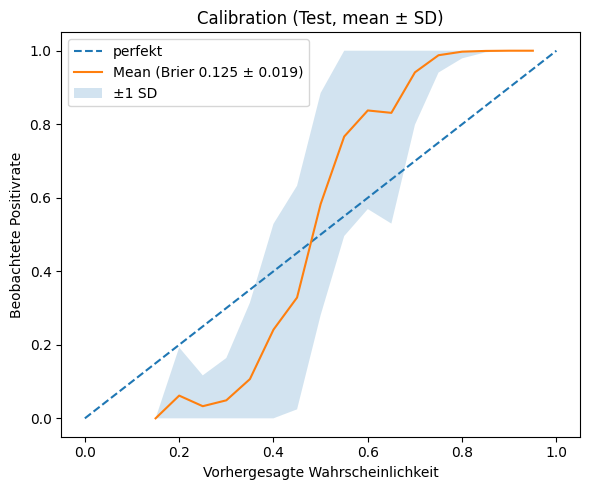

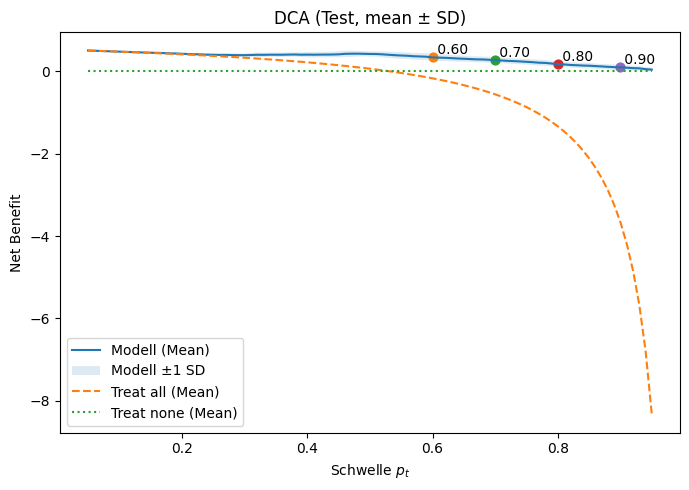


Internal OOF 95% CIs (Bootstrap)
AUROC: 0.944 (0.882–0.988)
AUPRC: 0.960 (0.910–0.991)
Brier: 0.124 (0.101–0.152)

Fixed threshold (Youden on OOF): 0.506

Internal thresholded metrics at t=0.51 (Bootstrap 95% CIs)
Accuracy: 0.907 (0.840–0.960)
F1: 0.909 (0.833–0.966)
Precision: 0.946 (0.862–1.000)
Recall: 0.875 (0.762–0.973)

External performance 95% CIs (Bootstrap)
AUROC: 0.689 (0.561–0.816)
AUPRC: 0.721 (0.604–0.839)
Brier: 0.279 (0.213–0.341)
Accuracy: 0.618 (0.515–0.735)
F1: 0.667 (0.575–0.759)
Precision: 0.565 (0.489–0.659)
Recall: 0.812 (0.656–0.938)

Calibration (point estimates):
  Intercept (CITL): -0.519
  Slope:            0.410
  Brier:            0.279

External calibration 95% CIs (Bootstrap)
Intercept: -0.519 (-1.083–-0.224)
Slope: 0.410 (0.139–0.815)
Brier: 0.279 (0.213–0.341)
ECE: 0.239 (0.194–0.356)


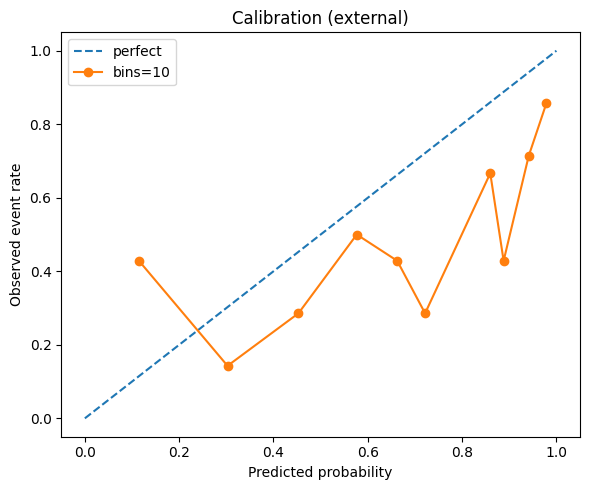

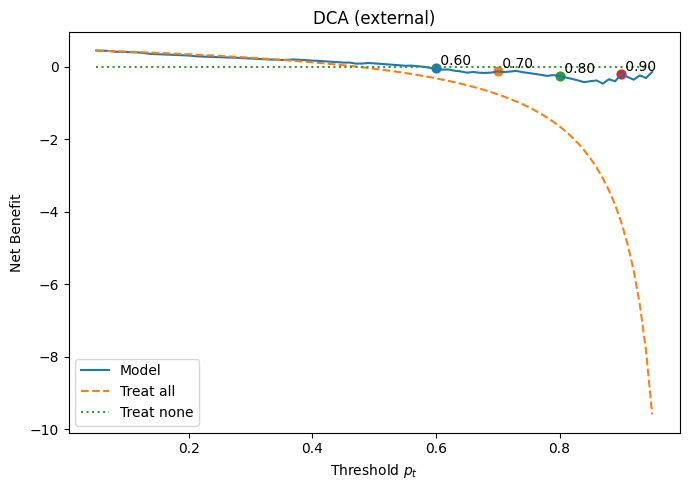

In [4]:

import os
import json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from joblib import dump, load

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, brier_score_loss, roc_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

# =======================
# KONFIGURATION
# =======================
CONFIG = {
    "target_col": "Verletzungsstatus",
    "normalize_headers": False,    # auf True setzen, wenn du Header robust normalisieren willst
    "ignore_cols": [],             # optional: z.B. IDs, die nicht in die Features dürfen
    "model_name": "logreg",        # "logreg" oder "svc"
    "logreg": {
        "solver": "liblinear",
        "penalty": "l2",
        "C": 1.0,
        "class_weight": None,      # oder "balanced"
        "max_iter": 200
    },
    "svc": {
        "kernel": "rbf",
        "C": 1.0,
        "gamma": "scale",
        "class_weight": None,      # oder "balanced"
        "calibrate": True,         # True: CalibratedClassifierCV, False: SVC(probability=True)
        "calibration_method": "sigmoid",
        "calibration_cv": 5
    },
    "cv": {
        "splits": 5,
        "repeats": 10,
        "random_state": 42
    },
    "artifacts_prefix": "locked_slim"
}

# =======================
# Utility (optional Header-Normalizer)
# =======================
import re
def _norm_header(s: str) -> str:
    if s is None: return ""
    s = str(s)
    s = s.replace("\u00A0"," ").replace("\u2009"," ").replace("\u202F"," ").replace("\u2007"," ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def maybe_normalize_headers(df: pd.DataFrame) -> pd.DataFrame:
    if not CONFIG["normalize_headers"]:
        return df
    cols = [_norm_header(c) for c in df.columns]
    # duplikate handhaben:
    seen = {}
    out_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            out_cols.append(c)
        else:
            seen[c] += 1
            out_cols.append(f"{c}_dup{seen[c]}")
    df2 = df.copy()
    df2.columns = out_cols
    return df2

# =======================
# Calibration & DCA
# =======================
def compute_calibration(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

def decision_curve(y_true, y_prob, thresholds=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model, nb_all = [], []
    nb_none = np.zeros_like(thresholds)
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb_model.append((TP / N) - (FP / N) * weight)
        nb_all.append(prevalence - (1 - prevalence) * weight)
    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

def aggregate_calibration(cal_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    mats = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"]); fp = np.asarray(c["frac_pos"])
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        mats.append(interp)
    M = np.vstack(mats)
    briers = np.array([c["brier"] for c in cal_list if "brier" in c])
    return {
        "grid": grid,
        "mean_frac_pos": np.nanmean(M, axis=0),
        "std_frac_pos":  np.nanstd(M, axis=0),
        "brier_mean": float(np.mean(briers)) if len(briers) else np.nan,
        "brier_std":  float(np.std(briers))  if len(briers) else np.nan
    }

def aggregate_dca(dca_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    nb_m, nb_a, nb_n = [], [], []
    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m.append(np.interp(grid, th, np.asarray(d["nb_model"])))
        nb_a.append(np.interp(grid, th, np.asarray(d["nb_all"])))
        nb_n.append(np.interp(grid, th, np.asarray(d["nb_none"])))
    nb_m = np.vstack(nb_m); nb_a = np.vstack(nb_a); nb_n = np.vstack(nb_n)
    return {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_m, axis=0), "nb_model_std": np.std(nb_m, axis=0),
        "nb_all_mean":   np.mean(nb_a, axis=0), "nb_all_std":   np.std(nb_a, axis=0),
        "nb_none_mean":  np.mean(nb_n, axis=0), "nb_none_std":  np.std(nb_n, axis=0),
    }

def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]
    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit"); plt.ylabel("Beobachtete Positivrate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"]-dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"]+dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Schwelle $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# =======================
# Bootstrap-Intervalle & Kalibration
# =======================
def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

def bootstrap_ci_internal_oof(y, p, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    A,U,Bs = [],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
    pct = lambda v: (float(np.percentile(v,2.5)), float(np.percentile(v,97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs))}

def bootstrap_ci_thresholded(y, p, thr, B=2000, seed=42):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    def safe(f, yt, yp):
        try: return f(yt, yp)
        except Exception: return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return (accuracy_score(y_, yhat),
                safe(f1_score, y_, yhat),
                safe(precision_score, y_, yhat),
                safe(recall_score, y_, yhat))
    pt = metrics(y, p)
    ACC,F1,PR,RE = [],[],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        a,f,pr,re = metrics(y[s], p[s])
        ACC.append(a); F1.append(f); PR.append(pr); RE.append(re)
    pct = lambda v: (float(np.nanpercentile(v,2.5)), float(np.nanpercentile(v,97.5)))
    return {"Accuracy": (pt[0], pct(ACC)),
            "F1":       (pt[1], pct(F1)),
            "Precision":(pt[2], pct(PR)),
            "Recall":   (pt[3], pct(RE))}

from sklearn.linear_model import LogisticRegression as _LR  # reuse import above
def _logit(p, eps=1e-8):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def calibration_intercept_slope(y, p):
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1,1)
    lr = _LR(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0,0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    return intercept, slope, brier

def expected_calibration_error(y, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

def bootstrap_ci_external(y, p, thr, B=2000, seed=42):
    import numpy as np
    from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                                 accuracy_score, f1_score, precision_score, recall_score)

    # Robust gegen np.float*
    B = int(B)

    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    def safe(f, yt, yp):
        try:
            return f(yt, yp)
        except Exception:
            return float("nan")

    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        auroc = roc_auc_score(y_, p_)
        auprc = safe(average_precision_score, y_, p_)
        brier = brier_score_loss(y_, p_)
        acc   = accuracy_score(y_, yhat)
        f1    = safe(f1_score, y_, yhat)
        prec  = safe(precision_score, y_, yhat)
        rec   = safe(recall_score, y_, yhat)
        return auroc, auprc, brier, acc, f1, prec, rec

    # Punktwerte
    pt = metrics(y, p)

    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)

    A, U, Bs, Ac, F1, Pr, Re = [], [], [], [], [], [], []
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        a, u, b, ac, f, pr, re = metrics(y[s], p[s])
        A.append(a); U.append(u); Bs.append(b); Ac.append(ac); F1.append(f); Pr.append(pr); Re.append(re)

    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {
        "AUROC":    (pt[0], pct(A)),
        "AUPRC":    (pt[1], pct(U)),
        "Brier":    (pt[2], pct(Bs)),
        "Accuracy": (pt[3], pct(Ac)),
        "F1":       (pt[4], pct(F1)),
        "Precision":(pt[5], pct(Pr)),
        "Recall":   (pt[6], pct(Re)),
    }

def bootstrap_ci_calibration(y, p, B=2000, seed=42, n_bins=10):
    import numpy as np
    # Robust gegen np.float* / Floats
    B = int(B)
    n_bins = int(n_bins)

    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    def calib(y_, p_):
        I, S, Brier = calibration_intercept_slope(y_, p_)
        E = expected_calibration_error(y_, p_, n_bins=n_bins)
        return I, S, Brier, E

    I, S, Brier, E = calib(y, p)

    I_, S_, B_, E_ = [], [], [], []
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)

    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            # Fallback falls eine Klasse leer ist
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        i, s_, b, e = calib(y[s], p[s])
        I_.append(i); S_.append(s_); B_.append(b); E_.append(e)

    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {
        "Intercept": (I, pct(I_)),
        "Slope":     (S, pct(S_)),
        "Brier":     (Brier, pct(B_)),
        "ECE":       (E, pct(E_)),
    }


# =======================
# Model builder (Umschalter)
# =======================
def build_estimator(name: str):
    if name.lower() == "logreg":
        p = CONFIG["logreg"]
        return LogisticRegression(
            solver=p["solver"],
            penalty=p["penalty"],
            C=p["C"],
            class_weight=p["class_weight"],
            max_iter=p["max_iter"]
        )
    elif name.lower() == "svc":
        p = CONFIG["svc"]
        if p["calibrate"]:
            base = SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                       class_weight=p["class_weight"], probability=False)
            return CalibratedClassifierCV(base_estimator=base,
                                          method=p["calibration_method"],
                                          cv=p["calibration_cv"])
        else:
            return SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                       class_weight=p["class_weight"], probability=True)
    else:
        raise ValueError("model_name must be 'logreg' or 'svc'.")

# =======================
# CV-Pipeline (ohne Augmentation)
# =======================
def run_cv_pipeline(data_path, target_column="Verletzungsstatus",
                    cv_splits=5, cv_repeats=10, verbose=True):
    try:
        df = pd.read_excel(data_path, sheet_name=0)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    df = maybe_normalize_headers(df)
    if target_column not in df.columns:
        print(f"Target column '{target_column}' not in data.")
        return None

    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column] + CONFIG["ignore_cols"], errors="ignore").copy()

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        try:
            print(f"Class distribution: {y.value_counts().to_dict()}")
        except Exception:
            pass

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats,
                                 random_state=CONFIG["cv"]["random_state"])

    metrics_results, cal_list, dca_list = [], [], []

    oof_true  = y.to_numpy().astype(int)
    oof_pred  = np.zeros(len(X), dtype=float)
    oof_sum   = np.zeros(len(X), dtype=float)
    oof_count = np.zeros(len(X), dtype=int)

    model_name = CONFIG["model_name"]
    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose:
            print(f"\n--- Fold {fold} ---")
        X_train, y_train = X.iloc[tr].copy(), y.iloc[tr].copy()
        X_test,  y_test  = X.iloc[te].copy(), y.iloc[te].copy()

        scaler = MinMaxScaler()
        X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
        X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

        est = build_estimator(model_name)
        est.fit(X_train_sc, y_train)

        # Vorhersagen (Probas)
        if hasattr(est, "predict_proba"):
            y_pred_prob = est.predict_proba(X_test_sc)[:,1]
            y_train_prob = est.predict_proba(X_train_sc)[:,1]
        else:
            # Fallback: decision_function → via sigmoid auf (0,1) bringen
            from scipy.special import expit
            y_pred_prob = expit(est.decision_function(X_test_sc))
            y_train_prob = expit(est.decision_function(X_train_sc))

        oof_sum[te]   += y_pred_prob
        oof_count[te] += 1

        # temporäre binäre 0.5-Schwelle (nur für Fold-Reporting)
        y_pred = (y_pred_prob >= 0.5).astype(int)
        train_pred = (y_train_prob >= 0.5).astype(int)

        fold_metrics = {
            'train_accuracy': accuracy_score(y_train, train_pred),
            'test_accuracy':  accuracy_score(y_test, y_pred),
            'f1_score':       f1_score(y_test, y_pred, zero_division=0),
            'precision':      precision_score(y_test, y_pred, zero_division=0),
            'recall':         recall_score(y_test, y_pred, zero_division=0),
            'roc_auc':        roc_auc_score(y_test, y_pred_prob),
        }
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        fold_metrics['brier_score'] = cal["brier"]
        cal_list.append(cal)

        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05,0.95,91))
        dca_list.append(dca)

        metrics_results.append(fold_metrics)

    # OOF mitteln
    mask = oof_count > 0
    oof_pred[mask] = oof_sum[mask] / oof_count[mask]

    # Aggregierte Tables
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg, (oof_true, oof_pred, df, X.columns.tolist())

# =======================
# Youden & Freezing
# =======================
def determine_fixed_threshold_youden(oof_true, oof_pred):
    fpr, tpr, thr = roc_curve(oof_true, oof_pred)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def freeze_pipeline_for_external(df, feature_order, fixed_threshold, save_prefix="locked_slim"):
    y_all = df[CONFIG["target_col"]].astype(int).to_numpy()
    X_all = df.drop(columns=[CONFIG["target_col"]] + CONFIG["ignore_cols"], errors="ignore").copy()
    # exakt gleiche Spaltenreihenfolge
    X_all = X_all[feature_order].copy()

    scaler = MinMaxScaler()
    X_all_sc = pd.DataFrame(scaler.fit_transform(X_all), columns=feature_order)

    est = build_estimator(CONFIG["model_name"])
    est.fit(X_all_sc, y_all)

    dump(est, f"{save_prefix}_model.joblib")
    dump(scaler, f"{save_prefix}_scaler.joblib")
    dump(feature_order, f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json", "w") as f:
        json.dump({"fixed_threshold": float(fixed_threshold),
                   "target_col": CONFIG["target_col"],
                   "model_name": CONFIG["model_name"]}, f)

# =======================
# Externe Validierung
# =======================
def plot_calibration_single(y, p, n_bins=10, title="Calibration (external)"):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(6,5))
    plt.plot([0,1], [0,1], '--', label="perfect")
    plt.plot(mean_pred, frac_pos, marker='o', label=f"bins={n_bins}")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed event rate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_single(dca, mark_pts=None, title="DCA (external)"):
    th = dca["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca["nb_model"], label="Model")
    plt.plot(th, dca["nb_all"], '--', label="Treat all")
    plt.plot(th, dca["nb_none"], ':', label="Treat none")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca["nb_model"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def external_validate_locked(external_path, save_prefix="locked_slim",
                             n_bins=10, dca_marks=[0.60,0.70,0.80,0.90]):
    est   = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr = float(meta["fixed_threshold"]); target_col = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)

    X_ext = df_ext[feature_order].copy()   # identische Spaltenreihenfolge
    y_ext = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        from scipy.special import expit
        p_ext = expit(est.decision_function(X_ext_sc))

    stats = bootstrap_ci_external(y_ext, p_ext, thr, B=2000)
    print_ci_block("External performance 95% CIs (Bootstrap)", stats)

    I,S,B = calibration_intercept_slope(y_ext, p_ext)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")

    cal_ci = bootstrap_ci_calibration(y_ext, p_ext, B=2000, n_bins=n_bins)
    print_ci_block("External calibration 95% CIs (Bootstrap)", cal_ci)
    plot_calibration_single(y_ext, p_ext, n_bins=n_bins, title="Calibration (external)")

    dca = decision_curve(y_ext, p_ext, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title="DCA (external)")

# =======================
# MAIN
# =======================
def main():
    # ==== PFADE ANPASSEN ====
    INTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Maestroni_ML_matched.xlsx"
    EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Motum_ML_matched.xlsx"

    # ========================

    res = run_cv_pipeline(
        INTERNAL_PATH,
        target_column=CONFIG["target_col"],
        cv_splits=CONFIG["cv"]["splits"],
        cv_repeats=CONFIG["cv"]["repeats"],
        verbose=True
    )
    if res is None:
        print("Pipeline failed."); return
    aggregated_results, cal_agg, dca_agg, (oof_true, oof_pred, df_all, feature_order) = res

    print("\n=== Model Performance Summary (CV folds) ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60,0.70,0.80,0.90], title="DCA (Test, mean ± SD)")

    oof_ci = bootstrap_ci_internal_oof(oof_true, oof_pred, B=2000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    fixed_threshold = determine_fixed_threshold_youden(oof_true, oof_pred)
    print(f"\nFixed threshold (Youden on OOF): {fixed_threshold:.3f}")

    th_ci = bootstrap_ci_thresholded(oof_true, oof_pred, thr=fixed_threshold, B=2000)
    print_ci_block(f"Internal thresholded metrics at t={fixed_threshold:.2f} (Bootstrap 95% CIs)", th_ci)

    # Freeze Artefakte
    freeze_pipeline_for_external(df_all, feature_order, fixed_threshold, save_prefix=CONFIG["artifacts_prefix"])

    # Externe Validierung
    if os.path.exists(EXTERNAL_PATH):
        external_validate_locked(EXTERNAL_PATH, save_prefix=CONFIG["artifacts_prefix"],
                                 n_bins=10, dca_marks=[0.60,0.70,0.80,0.90])
    else:
        print(f"\n[Hint] External validation file not found:\n{EXTERNAL_PATH}\n"
              f"→ Set EXTERNAL_PATH to your file and re-run.")

if __name__ == "__main__":
    main()


### Nachkalibrierung


=== External Calibration: BEFORE vs AFTER recalibration ===
Before  -> CITL: -0.519 | Slope: 0.410 | Brier: 0.279
After   -> CITL: -0.012 | Slope: 0.892 | Brier: 0.220  (Platt (logistic))

=== Thresholded metrics at INTERNAL threshold t=0.51 ===

Before recalibration
AUROC: 0.689 (0.561–0.816)
AUPRC: 0.721 (0.604–0.839)
Brier: 0.279 (0.213–0.341)
Accuracy: 0.618 (0.515–0.735)
F1: 0.667 (0.575–0.759)
Precision: 0.565 (0.489–0.659)
Recall: 0.812 (0.656–0.938)

After recalibration (Platt (logistic))
AUROC: 0.689 (0.561–0.816)
AUPRC: 0.721 (0.604–0.839)
Brier: 0.220 (0.185–0.255)
Accuracy: 0.662 (0.544–0.765)
F1: 0.610 (0.459–0.737)
Precision: 0.667 (0.522–0.821)
Recall: 0.562 (0.406–0.719)

=== Thresholded metrics at EXTERNAL Youden threshold t=0.55 (on recalibrated p) ===

After recalibration + external Youden (Platt (logistic))
AUROC: 0.689 (0.561–0.816)
AUPRC: 0.721 (0.604–0.839)
Brier: 0.220 (0.185–0.255)
Accuracy: 0.676 (0.573–0.779)
F1: 0.621 (0.464–0.746)
Precision: 0.692 (0.550–0

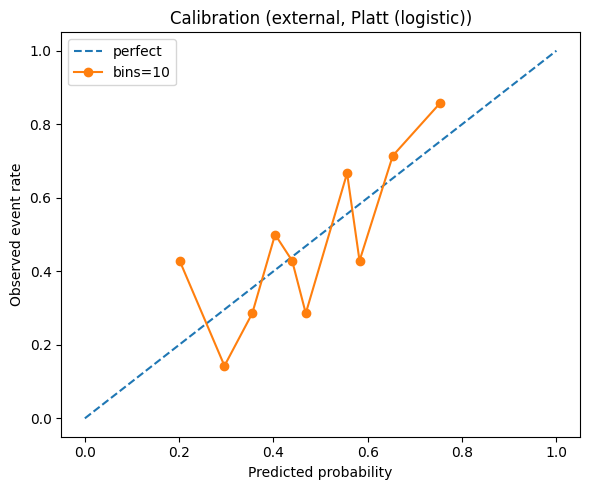

[Plot] DCA (recalibrated)


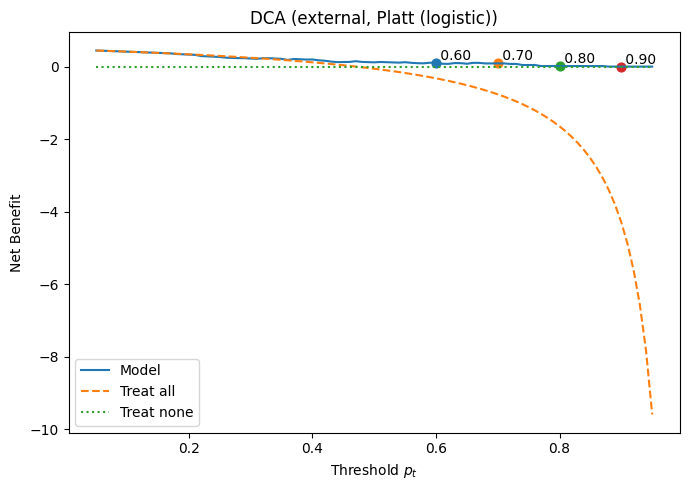

In [5]:
# === Recalibration block: run in a new cell AFTER your freeze + external_validate_locked ===
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from scipy.special import expit

EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Motum_ML_matched.xlsx"

def recalibrate_external(external_path,
                         save_prefix="locked_slim",
                         method="platt",               # "platt" oder "isotonic"
                         also_compute_external_youden=True,
                         n_bins=10,
                         dca_marks=[0.60,0.70,0.80,0.90]):
    """
    Post-hoc Re-Kalibration auf externen Daten + Metriken neu berechnen.
    Erwartet, dass Freeze-Artefakte (Model, Scaler, Feature-Order, Meta) bereits existieren.
    Greift NICHT ins Modell ein, kalibriert nur die externen p.
    """
    # --- Artefakte & Daten laden (wie in external_validate_locked) ---
    est    = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr_internal = float(meta["fixed_threshold"])
    target_col   = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)
    X_ext  = df_ext[feature_order].copy()
    y_ext  = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        p_ext = expit(est.decision_function(X_ext_sc))

    # --- Re-Kalibration ---
    if method.lower() == "platt":
        # Platt scaling: LR auf logit(p) ~ y
        z = _logit(p_ext)[:, None]
        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(z, y_ext)
        p_ext_cal = lr.predict_proba(z)[:, 1]
        cal_label = "Platt (logistic)"
    elif method.lower() == "isotonic":
        iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
        p_ext_cal = iso.fit_transform(p_ext, y_ext)
        cal_label = "Isotonic"
    else:
        raise ValueError("method must be 'platt' or 'isotonic'.")

    # --- Reporting: Kalibration vor/nach ---
    print("\n=== External Calibration: BEFORE vs AFTER recalibration ===")
    I0,S0,B0 = calibration_intercept_slope(y_ext, p_ext)
    I1,S1,B1 = calibration_intercept_slope(y_ext, p_ext_cal)
    print(f"Before  -> CITL: {I0:.3f} | Slope: {S0:.3f} | Brier: {B0:.3f}")
    print(f"After   -> CITL: {I1:.3f} | Slope: {S1:.3f} | Brier: {B1:.3f}  ({cal_label})")

    # --- Schwellenabhängige Metriken mit interner Schwelle (fairer Vergleich) ---
    print(f"\n=== Thresholded metrics at INTERNAL threshold t={thr_internal:.2f} ===")
    stats_thr_int_before = bootstrap_ci_external(y_ext, p_ext,     thr_internal, B=2000)
    stats_thr_int_after  = bootstrap_ci_external(y_ext, p_ext_cal, thr_internal, B=2000)
    print_ci_block("Before recalibration", stats_thr_int_before)
    print_ci_block(f"After recalibration ({cal_label})", stats_thr_int_after)

    # --- Optional: neue externe Youden-Schwelle auf rekalibrierten p ---
    if also_compute_external_youden:
        thr_ext = determine_fixed_threshold_youden(y_ext, p_ext_cal)
        print(f"\n=== Thresholded metrics at EXTERNAL Youden threshold t={thr_ext:.2f} (on recalibrated p) ===")
        stats_thr_ext = bootstrap_ci_external(y_ext, p_ext_cal, thr_ext, B=2000)
        print_ci_block(f"After recalibration + external Youden ({cal_label})", stats_thr_ext)

    # --- Kalibrations- und DCA-Plots (nach Re-Kalibration) ---
    print("\n[Plot] Calibration curve (recalibrated)")
    plot_calibration_single(y_ext, p_ext_cal, n_bins=n_bins,
                            title=f"Calibration (external, {cal_label})")

    print("[Plot] DCA (recalibrated)")
    dca = decision_curve(y_ext, p_ext_cal, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title=f"DCA (external, {cal_label})")

    # --- Rückgabe, falls du weiterarbeiten willst ---
    return {
        "p_ext_raw": p_ext,
        "p_ext_cal": p_ext_cal,
        "thr_internal": thr_internal,
        "thr_external_youden": thr_ext if also_compute_external_youden else None
    }

# Recalibration run
_ = recalibrate_external(
        external_path=EXTERNAL_PATH,
        save_prefix=CONFIG["artifacts_prefix"],  # identisch wie beim Freeze
        method="platt",                          # oder "isotonic"
        also_compute_external_youden=True,       # auch neue externe Youden-Schwelle berechnen
        n_bins=10                                # Anzahl Bins für Kalibrationskurve
    )



### Externe Validierung (LogReg) - Motum intern und Maestroni extern

Data loaded: 68 samples, 25 features
Class distribution: {0: 36, 1: 32}

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---

--- Fold 6 ---

--- Fold 7 ---

--- Fold 8 ---

--- Fold 9 ---

--- Fold 10 ---

--- Fold 11 ---

--- Fold 12 ---

--- Fold 13 ---

--- Fold 14 ---

--- Fold 15 ---

--- Fold 16 ---

--- Fold 17 ---

--- Fold 18 ---

--- Fold 19 ---

--- Fold 20 ---

--- Fold 21 ---

--- Fold 22 ---

--- Fold 23 ---

--- Fold 24 ---

--- Fold 25 ---

--- Fold 26 ---

--- Fold 27 ---

--- Fold 28 ---

--- Fold 29 ---

--- Fold 30 ---

--- Fold 31 ---

--- Fold 32 ---

--- Fold 33 ---

--- Fold 34 ---

--- Fold 35 ---

--- Fold 36 ---

--- Fold 37 ---

--- Fold 38 ---

--- Fold 39 ---

--- Fold 40 ---

--- Fold 41 ---

--- Fold 42 ---

--- Fold 43 ---

--- Fold 44 ---

--- Fold 45 ---

--- Fold 46 ---

--- Fold 47 ---

--- Fold 48 ---

--- Fold 49 ---

--- Fold 50 ---

=== Model Performance Summary (CV folds) ===
Metric          Mean                 Std 

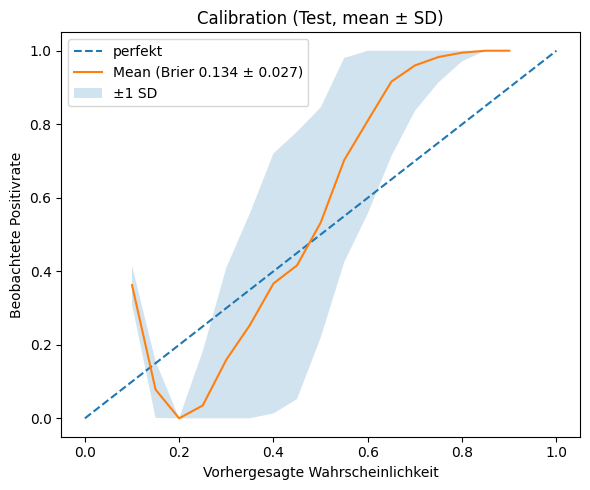

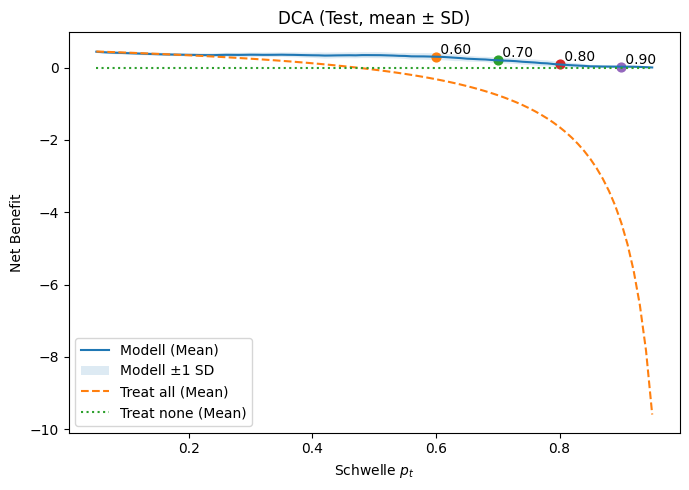


Internal OOF 95% CIs (Bootstrap)
AUROC: 0.927 (0.844–0.983)
AUPRC: 0.943 (0.874–0.984)
Brier: 0.133 (0.104–0.170)

Fixed threshold (Youden on OOF): 0.496

Internal thresholded metrics at t=0.50 (Bootstrap 95% CIs)
Accuracy: 0.897 (0.824–0.956)
F1: 0.881 (0.778–0.957)
Precision: 0.963 (0.875–1.000)
Recall: 0.812 (0.667–0.938)

External performance 95% CIs (Bootstrap)
AUROC: 0.779 (0.667–0.880)
AUPRC: 0.807 (0.711–0.902)
Brier: 0.516 (0.487–0.533)
Accuracy: 0.480 (0.467–0.507)
F1: 0.049 (0.000–0.140)
Precision: 1.000 (0.000–1.000)
Recall: 0.025 (0.000–0.075)

Calibration (point estimates):
  Intercept (CITL): 3.832
  Slope:            0.291
  Brier:            0.516

External calibration 95% CIs (Bootstrap)
Intercept: 3.832 (2.145–7.062)
Slope: 0.291 (0.161–0.531)
Brier: 0.516 (0.487–0.533)
ECE: 0.520 (0.491–0.553)


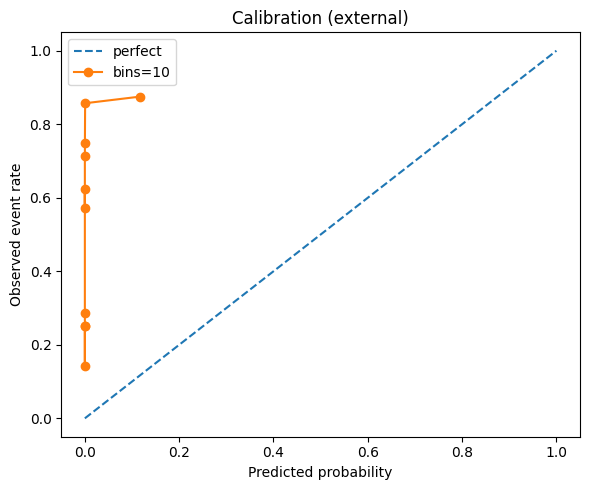

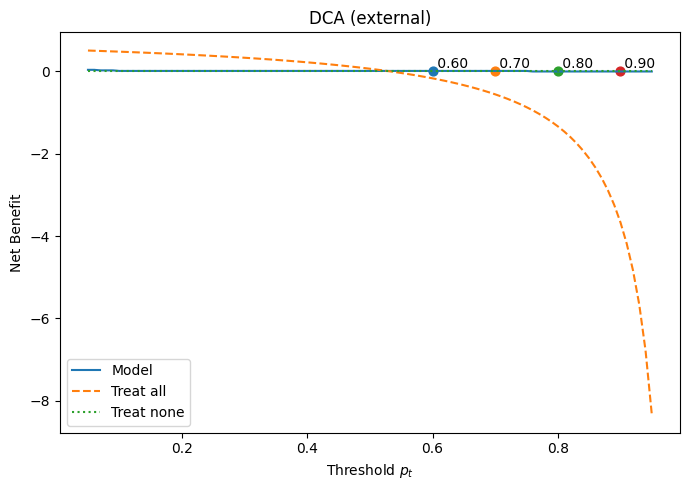

In [6]:

import os
import json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from joblib import dump, load

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, brier_score_loss, roc_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

# =======================
# KONFIGURATION
# =======================
CONFIG = {
    "target_col": "Verletzungsstatus",
    "normalize_headers": False,    # auf True setzen, wenn du Header robust normalisieren willst
    "ignore_cols": [],             # optional: z.B. IDs, die nicht in die Features dürfen
    "model_name": "logreg",        # "logreg" oder "svc"
    "logreg": {
        "solver": "liblinear",
        "penalty": "l2",
        "C": 1.0,
        "class_weight": None,      # oder "balanced"
        "max_iter": 200
    },
    "svc": {
        "kernel": "rbf",
        "C": 1.0,
        "gamma": "scale",
        "class_weight": None,      # oder "balanced"
        "calibrate": True,         # True: CalibratedClassifierCV, False: SVC(probability=True)
        "calibration_method": "sigmoid",
        "calibration_cv": 5
    },
    "cv": {
        "splits": 5,
        "repeats": 10,
        "random_state": 42
    },
    "artifacts_prefix": "locked_slim"
}

# =======================
# Utility (optional Header-Normalizer)
# =======================
import re
def _norm_header(s: str) -> str:
    if s is None: return ""
    s = str(s)
    s = s.replace("\u00A0"," ").replace("\u2009"," ").replace("\u202F"," ").replace("\u2007"," ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def maybe_normalize_headers(df: pd.DataFrame) -> pd.DataFrame:
    if not CONFIG["normalize_headers"]:
        return df
    cols = [_norm_header(c) for c in df.columns]
    # duplikate handhaben:
    seen = {}
    out_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            out_cols.append(c)
        else:
            seen[c] += 1
            out_cols.append(f"{c}_dup{seen[c]}")
    df2 = df.copy()
    df2.columns = out_cols
    return df2

# =======================
# Calibration & DCA
# =======================
def compute_calibration(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

def decision_curve(y_true, y_prob, thresholds=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model, nb_all = [], []
    nb_none = np.zeros_like(thresholds)
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb_model.append((TP / N) - (FP / N) * weight)
        nb_all.append(prevalence - (1 - prevalence) * weight)
    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

def aggregate_calibration(cal_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    mats = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"]); fp = np.asarray(c["frac_pos"])
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        mats.append(interp)
    M = np.vstack(mats)
    briers = np.array([c["brier"] for c in cal_list if "brier" in c])
    return {
        "grid": grid,
        "mean_frac_pos": np.nanmean(M, axis=0),
        "std_frac_pos":  np.nanstd(M, axis=0),
        "brier_mean": float(np.mean(briers)) if len(briers) else np.nan,
        "brier_std":  float(np.std(briers))  if len(briers) else np.nan
    }

def aggregate_dca(dca_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    nb_m, nb_a, nb_n = [], [], []
    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m.append(np.interp(grid, th, np.asarray(d["nb_model"])))
        nb_a.append(np.interp(grid, th, np.asarray(d["nb_all"])))
        nb_n.append(np.interp(grid, th, np.asarray(d["nb_none"])))
    nb_m = np.vstack(nb_m); nb_a = np.vstack(nb_a); nb_n = np.vstack(nb_n)
    return {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_m, axis=0), "nb_model_std": np.std(nb_m, axis=0),
        "nb_all_mean":   np.mean(nb_a, axis=0), "nb_all_std":   np.std(nb_a, axis=0),
        "nb_none_mean":  np.mean(nb_n, axis=0), "nb_none_std":  np.std(nb_n, axis=0),
    }

def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]
    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit"); plt.ylabel("Beobachtete Positivrate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"]-dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"]+dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Schwelle $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# =======================
# Bootstrap-Intervalle & Kalibration
# =======================
def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

def bootstrap_ci_internal_oof(y, p, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    A,U,Bs = [],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
    pct = lambda v: (float(np.percentile(v,2.5)), float(np.percentile(v,97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs))}

def bootstrap_ci_thresholded(y, p, thr, B=2000, seed=42):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    def safe(f, yt, yp):
        try: return f(yt, yp)
        except Exception: return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return (accuracy_score(y_, yhat),
                safe(f1_score, y_, yhat),
                safe(precision_score, y_, yhat),
                safe(recall_score, y_, yhat))
    pt = metrics(y, p)
    ACC,F1,PR,RE = [],[],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        a,f,pr,re = metrics(y[s], p[s])
        ACC.append(a); F1.append(f); PR.append(pr); RE.append(re)
    pct = lambda v: (float(np.nanpercentile(v,2.5)), float(np.nanpercentile(v,97.5)))
    return {"Accuracy": (pt[0], pct(ACC)),
            "F1":       (pt[1], pct(F1)),
            "Precision":(pt[2], pct(PR)),
            "Recall":   (pt[3], pct(RE))}

from sklearn.linear_model import LogisticRegression as _LR  # reuse import above
def _logit(p, eps=1e-8):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def calibration_intercept_slope(y, p):
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1,1)
    lr = _LR(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0,0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    return intercept, slope, brier

def expected_calibration_error(y, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

def bootstrap_ci_external(y, p, thr, B=2000, seed=42):
    import numpy as np
    from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                                 accuracy_score, f1_score, precision_score, recall_score)

    # Robust gegen np.float*
    B = int(B)

    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    def safe(f, yt, yp):
        try:
            return f(yt, yp)
        except Exception:
            return float("nan")

    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        auroc = roc_auc_score(y_, p_)
        auprc = safe(average_precision_score, y_, p_)
        brier = brier_score_loss(y_, p_)
        acc   = accuracy_score(y_, yhat)
        f1    = safe(f1_score, y_, yhat)
        prec  = safe(precision_score, y_, yhat)
        rec   = safe(recall_score, y_, yhat)
        return auroc, auprc, brier, acc, f1, prec, rec

    # Punktwerte
    pt = metrics(y, p)

    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)

    A, U, Bs, Ac, F1, Pr, Re = [], [], [], [], [], [], []
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        a, u, b, ac, f, pr, re = metrics(y[s], p[s])
        A.append(a); U.append(u); Bs.append(b); Ac.append(ac); F1.append(f); Pr.append(pr); Re.append(re)

    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {
        "AUROC":    (pt[0], pct(A)),
        "AUPRC":    (pt[1], pct(U)),
        "Brier":    (pt[2], pct(Bs)),
        "Accuracy": (pt[3], pct(Ac)),
        "F1":       (pt[4], pct(F1)),
        "Precision":(pt[5], pct(Pr)),
        "Recall":   (pt[6], pct(Re)),
    }

def bootstrap_ci_calibration(y, p, B=2000, seed=42, n_bins=10):
    import numpy as np
    # Robust gegen np.float* / Floats
    B = int(B)
    n_bins = int(n_bins)

    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    def calib(y_, p_):
        I, S, Brier = calibration_intercept_slope(y_, p_)
        E = expected_calibration_error(y_, p_, n_bins=n_bins)
        return I, S, Brier, E

    I, S, Brier, E = calib(y, p)

    I_, S_, B_, E_ = [], [], [], []
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)

    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            # Fallback falls eine Klasse leer ist
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        i, s_, b, e = calib(y[s], p[s])
        I_.append(i); S_.append(s_); B_.append(b); E_.append(e)

    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {
        "Intercept": (I, pct(I_)),
        "Slope":     (S, pct(S_)),
        "Brier":     (Brier, pct(B_)),
        "ECE":       (E, pct(E_)),
    }


# =======================
# Model builder (Umschalter)
# =======================
def build_estimator(name: str):
    if name.lower() == "logreg":
        p = CONFIG["logreg"]
        return LogisticRegression(
            solver=p["solver"],
            penalty=p["penalty"],
            C=p["C"],
            class_weight=p["class_weight"],
            max_iter=p["max_iter"]
        )
    elif name.lower() == "svc":
        p = CONFIG["svc"]
        if p["calibrate"]:
            base = SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                       class_weight=p["class_weight"], probability=False)
            return CalibratedClassifierCV(base_estimator=base,
                                          method=p["calibration_method"],
                                          cv=p["calibration_cv"])
        else:
            return SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                       class_weight=p["class_weight"], probability=True)
    else:
        raise ValueError("model_name must be 'logreg' or 'svc'.")

# =======================
# CV-Pipeline (ohne Augmentation)
# =======================
def run_cv_pipeline(data_path, target_column="Verletzungsstatus",
                    cv_splits=5, cv_repeats=10, verbose=True):
    try:
        df = pd.read_excel(data_path, sheet_name=0)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    df = maybe_normalize_headers(df)
    if target_column not in df.columns:
        print(f"Target column '{target_column}' not in data.")
        return None

    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column] + CONFIG["ignore_cols"], errors="ignore").copy()

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        try:
            print(f"Class distribution: {y.value_counts().to_dict()}")
        except Exception:
            pass

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats,
                                 random_state=CONFIG["cv"]["random_state"])

    metrics_results, cal_list, dca_list = [], [], []

    oof_true  = y.to_numpy().astype(int)
    oof_pred  = np.zeros(len(X), dtype=float)
    oof_sum   = np.zeros(len(X), dtype=float)
    oof_count = np.zeros(len(X), dtype=int)

    model_name = CONFIG["model_name"]
    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose:
            print(f"\n--- Fold {fold} ---")
        X_train, y_train = X.iloc[tr].copy(), y.iloc[tr].copy()
        X_test,  y_test  = X.iloc[te].copy(), y.iloc[te].copy()

        scaler = MinMaxScaler()
        X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
        X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

        est = build_estimator(model_name)
        est.fit(X_train_sc, y_train)

        # Vorhersagen (Probas)
        if hasattr(est, "predict_proba"):
            y_pred_prob = est.predict_proba(X_test_sc)[:,1]
            y_train_prob = est.predict_proba(X_train_sc)[:,1]
        else:
            # Fallback: decision_function → via sigmoid auf (0,1) bringen
            from scipy.special import expit
            y_pred_prob = expit(est.decision_function(X_test_sc))
            y_train_prob = expit(est.decision_function(X_train_sc))

        oof_sum[te]   += y_pred_prob
        oof_count[te] += 1

        # temporäre binäre 0.5-Schwelle (nur für Fold-Reporting)
        y_pred = (y_pred_prob >= 0.5).astype(int)
        train_pred = (y_train_prob >= 0.5).astype(int)

        fold_metrics = {
            'train_accuracy': accuracy_score(y_train, train_pred),
            'test_accuracy':  accuracy_score(y_test, y_pred),
            'f1_score':       f1_score(y_test, y_pred, zero_division=0),
            'precision':      precision_score(y_test, y_pred, zero_division=0),
            'recall':         recall_score(y_test, y_pred, zero_division=0),
            'roc_auc':        roc_auc_score(y_test, y_pred_prob),
        }
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        fold_metrics['brier_score'] = cal["brier"]
        cal_list.append(cal)

        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05,0.95,91))
        dca_list.append(dca)

        metrics_results.append(fold_metrics)

    # OOF mitteln
    mask = oof_count > 0
    oof_pred[mask] = oof_sum[mask] / oof_count[mask]

    # Aggregierte Tables
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg, (oof_true, oof_pred, df, X.columns.tolist())

# =======================
# Youden & Freezing
# =======================
def determine_fixed_threshold_youden(oof_true, oof_pred):
    fpr, tpr, thr = roc_curve(oof_true, oof_pred)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def freeze_pipeline_for_external(df, feature_order, fixed_threshold, save_prefix="locked_slim"):
    y_all = df[CONFIG["target_col"]].astype(int).to_numpy()
    X_all = df.drop(columns=[CONFIG["target_col"]] + CONFIG["ignore_cols"], errors="ignore").copy()
    # exakt gleiche Spaltenreihenfolge
    X_all = X_all[feature_order].copy()

    scaler = MinMaxScaler()
    X_all_sc = pd.DataFrame(scaler.fit_transform(X_all), columns=feature_order)

    est = build_estimator(CONFIG["model_name"])
    est.fit(X_all_sc, y_all)

    dump(est, f"{save_prefix}_model.joblib")
    dump(scaler, f"{save_prefix}_scaler.joblib")
    dump(feature_order, f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json", "w") as f:
        json.dump({"fixed_threshold": float(fixed_threshold),
                   "target_col": CONFIG["target_col"],
                   "model_name": CONFIG["model_name"]}, f)

# =======================
# Externe Validierung
# =======================
def plot_calibration_single(y, p, n_bins=10, title="Calibration (external)"):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(6,5))
    plt.plot([0,1], [0,1], '--', label="perfect")
    plt.plot(mean_pred, frac_pos, marker='o', label=f"bins={n_bins}")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed event rate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_single(dca, mark_pts=None, title="DCA (external)"):
    th = dca["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca["nb_model"], label="Model")
    plt.plot(th, dca["nb_all"], '--', label="Treat all")
    plt.plot(th, dca["nb_none"], ':', label="Treat none")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca["nb_model"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def external_validate_locked(external_path, save_prefix="locked_slim",
                             n_bins=10, dca_marks=[0.60,0.70,0.80,0.90]):
    est   = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr = float(meta["fixed_threshold"]); target_col = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)

    X_ext = df_ext[feature_order].copy()   # identische Spaltenreihenfolge
    y_ext = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        from scipy.special import expit
        p_ext = expit(est.decision_function(X_ext_sc))

    stats = bootstrap_ci_external(y_ext, p_ext, thr, B=2000)
    print_ci_block("External performance 95% CIs (Bootstrap)", stats)

    I,S,B = calibration_intercept_slope(y_ext, p_ext)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")

    cal_ci = bootstrap_ci_calibration(y_ext, p_ext, B=2000, n_bins=n_bins)
    print_ci_block("External calibration 95% CIs (Bootstrap)", cal_ci)
    plot_calibration_single(y_ext, p_ext, n_bins=n_bins, title="Calibration (external)")

    dca = decision_curve(y_ext, p_ext, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title="DCA (external)")

# =======================
# MAIN
# =======================
def main():
    # ==== PFADE ANPASSEN ====
    INTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Motum_ML_matched.xlsx"
    EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Maestroni_ML_matched.xlsx"

    # ========================

    res = run_cv_pipeline(
        INTERNAL_PATH,
        target_column=CONFIG["target_col"],
        cv_splits=CONFIG["cv"]["splits"],
        cv_repeats=CONFIG["cv"]["repeats"],
        verbose=True
    )
    if res is None:
        print("Pipeline failed."); return
    aggregated_results, cal_agg, dca_agg, (oof_true, oof_pred, df_all, feature_order) = res

    print("\n=== Model Performance Summary (CV folds) ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60,0.70,0.80,0.90], title="DCA (Test, mean ± SD)")

    oof_ci = bootstrap_ci_internal_oof(oof_true, oof_pred, B=2000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    fixed_threshold = determine_fixed_threshold_youden(oof_true, oof_pred)
    print(f"\nFixed threshold (Youden on OOF): {fixed_threshold:.3f}")

    th_ci = bootstrap_ci_thresholded(oof_true, oof_pred, thr=fixed_threshold, B=2000)
    print_ci_block(f"Internal thresholded metrics at t={fixed_threshold:.2f} (Bootstrap 95% CIs)", th_ci)

    # Freeze Artefakte
    freeze_pipeline_for_external(df_all, feature_order, fixed_threshold, save_prefix=CONFIG["artifacts_prefix"])

    # Externe Validierung
    if os.path.exists(EXTERNAL_PATH):
        external_validate_locked(EXTERNAL_PATH, save_prefix=CONFIG["artifacts_prefix"],
                                 n_bins=10, dca_marks=[0.60,0.70,0.80,0.90])
    else:
        print(f"\n[Hint] External validation file not found:\n{EXTERNAL_PATH}\n"
              f"→ Set EXTERNAL_PATH to your file and re-run.")

if __name__ == "__main__":
    main()


### Nachkalibrieren 


=== External Calibration: BEFORE vs AFTER recalibration ===
Before  -> CITL: 3.832 | Slope: 0.291 | Brier: 0.516
After   -> CITL: 0.002 | Slope: 0.936 | Brier: 0.192  (Platt (logistic))

=== Thresholded metrics at INTERNAL threshold t=0.50 ===

Before recalibration
AUROC: 0.779 (0.667–0.880)
AUPRC: 0.807 (0.711–0.902)
Brier: 0.516 (0.487–0.533)
Accuracy: 0.480 (0.467–0.507)
F1: 0.049 (0.000–0.140)
Precision: 1.000 (0.000–1.000)
Recall: 0.025 (0.000–0.075)

After recalibration (Platt (logistic))
AUROC: 0.780 (0.669–0.881)
AUPRC: 0.807 (0.711–0.902)
Brier: 0.192 (0.151–0.236)
Accuracy: 0.707 (0.613–0.813)
F1: 0.711 (0.597–0.815)
Precision: 0.750 (0.643–0.871)
Recall: 0.675 (0.525–0.825)

=== Thresholded metrics at EXTERNAL Youden threshold t=0.47 (on recalibrated p) ===

After recalibration + external Youden (Platt (logistic))
AUROC: 0.780 (0.669–0.881)
AUPRC: 0.807 (0.711–0.902)
Brier: 0.192 (0.151–0.236)
Accuracy: 0.747 (0.640–0.840)
F1: 0.771 (0.675–0.854)
Precision: 0.744 (0.652–0.8

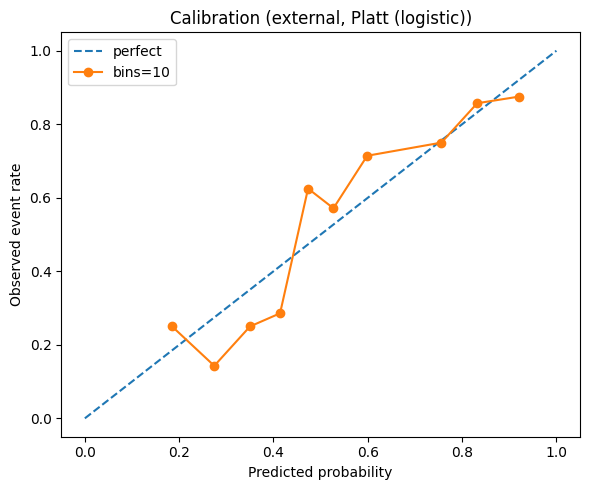

[Plot] DCA (recalibrated)


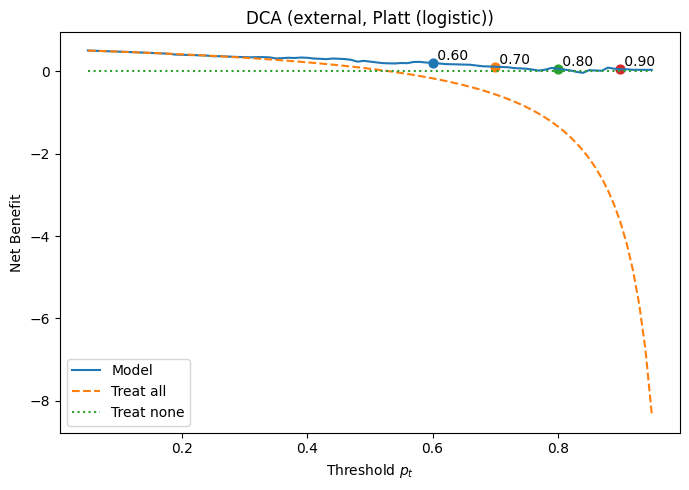

In [7]:
# === Recalibration block: run in a new cell AFTER your freeze + external_validate_locked ===
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from scipy.special import expit

EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Maestroni_ML_matched.xlsx"

def recalibrate_external(external_path,
                         save_prefix="locked_slim",
                         method="platt",               # "platt" oder "isotonic"
                         also_compute_external_youden=True,
                         n_bins=10,
                         dca_marks=[0.60,0.70,0.80,0.90]):
    """
    Post-hoc Re-Kalibration auf externen Daten + Metriken neu berechnen.
    Erwartet, dass Freeze-Artefakte (Model, Scaler, Feature-Order, Meta) bereits existieren.
    Greift NICHT ins Modell ein, kalibriert nur die externen p.
    """
    # --- Artefakte & Daten laden (wie in external_validate_locked) ---
    est    = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr_internal = float(meta["fixed_threshold"])
    target_col   = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)
    X_ext  = df_ext[feature_order].copy()
    y_ext  = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        p_ext = expit(est.decision_function(X_ext_sc))

    # --- Re-Kalibration ---
    if method.lower() == "platt":
        # Platt scaling: LR auf logit(p) ~ y
        z = _logit(p_ext)[:, None]
        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(z, y_ext)
        p_ext_cal = lr.predict_proba(z)[:, 1]
        cal_label = "Platt (logistic)"
    elif method.lower() == "isotonic":
        iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
        p_ext_cal = iso.fit_transform(p_ext, y_ext)
        cal_label = "Isotonic"
    else:
        raise ValueError("method must be 'platt' or 'isotonic'.")

    # --- Reporting: Kalibration vor/nach ---
    print("\n=== External Calibration: BEFORE vs AFTER recalibration ===")
    I0,S0,B0 = calibration_intercept_slope(y_ext, p_ext)
    I1,S1,B1 = calibration_intercept_slope(y_ext, p_ext_cal)
    print(f"Before  -> CITL: {I0:.3f} | Slope: {S0:.3f} | Brier: {B0:.3f}")
    print(f"After   -> CITL: {I1:.3f} | Slope: {S1:.3f} | Brier: {B1:.3f}  ({cal_label})")

    # --- Schwellenabhängige Metriken mit interner Schwelle (fairer Vergleich) ---
    print(f"\n=== Thresholded metrics at INTERNAL threshold t={thr_internal:.2f} ===")
    stats_thr_int_before = bootstrap_ci_external(y_ext, p_ext,     thr_internal, B=2000)
    stats_thr_int_after  = bootstrap_ci_external(y_ext, p_ext_cal, thr_internal, B=2000)
    print_ci_block("Before recalibration", stats_thr_int_before)
    print_ci_block(f"After recalibration ({cal_label})", stats_thr_int_after)

    # --- Optional: neue externe Youden-Schwelle auf rekalibrierten p ---
    if also_compute_external_youden:
        thr_ext = determine_fixed_threshold_youden(y_ext, p_ext_cal)
        print(f"\n=== Thresholded metrics at EXTERNAL Youden threshold t={thr_ext:.2f} (on recalibrated p) ===")
        stats_thr_ext = bootstrap_ci_external(y_ext, p_ext_cal, thr_ext, B=2000)
        print_ci_block(f"After recalibration + external Youden ({cal_label})", stats_thr_ext)

    # --- Kalibrations- und DCA-Plots (nach Re-Kalibration) ---
    print("\n[Plot] Calibration curve (recalibrated)")
    plot_calibration_single(y_ext, p_ext_cal, n_bins=n_bins,
                            title=f"Calibration (external, {cal_label})")

    print("[Plot] DCA (recalibrated)")
    dca = decision_curve(y_ext, p_ext_cal, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title=f"DCA (external, {cal_label})")

    # --- Rückgabe, falls du weiterarbeiten willst ---
    return {
        "p_ext_raw": p_ext,
        "p_ext_cal": p_ext_cal,
        "thr_internal": thr_internal,
        "thr_external_youden": thr_ext if also_compute_external_youden else None
    }

# Recalibration run
_ = recalibrate_external(
        external_path=EXTERNAL_PATH,
        save_prefix=CONFIG["artifacts_prefix"],  # identisch wie beim Freeze
        method="platt",                          # oder "isotonic"
        also_compute_external_youden=True,       # auch neue externe Youden-Schwelle berechnen
        n_bins=10                                # Anzahl Bins für Kalibrationskurve
    )



### Externe Validierung (SVC) - Maestroni intern und Motum extern

Data loaded: 75 samples, 25 features
Class distribution: {1: 40, 0: 35}

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---

--- Fold 6 ---

--- Fold 7 ---

--- Fold 8 ---

--- Fold 9 ---

--- Fold 10 ---

--- Fold 11 ---

--- Fold 12 ---

--- Fold 13 ---

--- Fold 14 ---

--- Fold 15 ---

--- Fold 16 ---

--- Fold 17 ---

--- Fold 18 ---

--- Fold 19 ---

--- Fold 20 ---

--- Fold 21 ---

--- Fold 22 ---

--- Fold 23 ---

--- Fold 24 ---

--- Fold 25 ---

--- Fold 26 ---

--- Fold 27 ---

--- Fold 28 ---

--- Fold 29 ---

--- Fold 30 ---

--- Fold 31 ---

--- Fold 32 ---

--- Fold 33 ---

--- Fold 34 ---

--- Fold 35 ---

--- Fold 36 ---

--- Fold 37 ---

--- Fold 38 ---

--- Fold 39 ---

--- Fold 40 ---

--- Fold 41 ---

--- Fold 42 ---

--- Fold 43 ---

--- Fold 44 ---

--- Fold 45 ---

--- Fold 46 ---

--- Fold 47 ---

--- Fold 48 ---

--- Fold 49 ---

--- Fold 50 ---

=== Model Performance Summary (CV folds) ===
Metric          Mean                 Std 

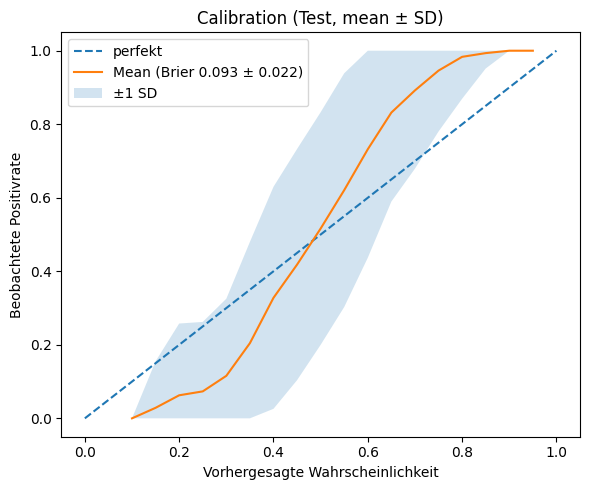

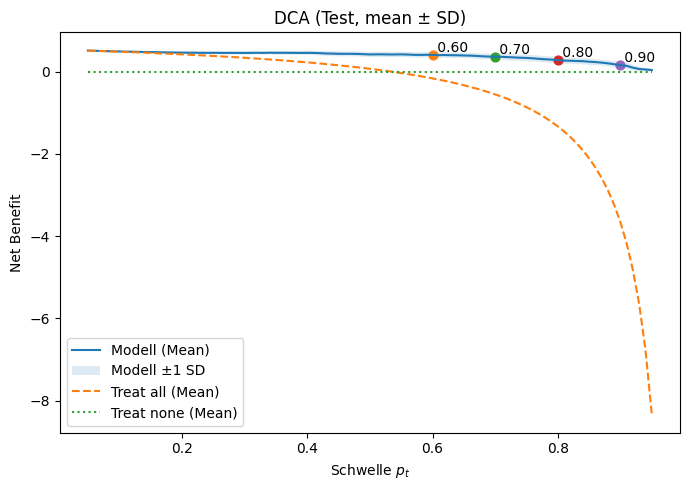


Internal OOF 95% CIs (Bootstrap)
AUROC: 0.961 (0.913–0.993)
AUPRC: 0.969 (0.930–0.994)
Brier: 0.091 (0.067–0.119)

Fixed threshold (Youden on OOF): 0.506

Internal thresholded metrics at t=0.51 (Bootstrap 95% CIs)
Accuracy: 0.907 (0.840–0.960)
F1: 0.914 (0.839–0.968)
Precision: 0.902 (0.800–0.978)
Recall: 0.925 (0.833–1.000)

External performance 95% CIs (Bootstrap)
AUROC: 0.610 (0.477–0.745)
AUPRC: 0.619 (0.509–0.753)
Brier: 0.375 (0.375–0.375)
Accuracy: 0.471 (0.471–0.471)
F1: 0.640 (0.640–0.640)
Precision: 0.471 (0.471–0.471)
Recall: 1.000 (1.000–1.000)

Calibration (point estimates):
  Intercept (CITL): -0.119
  Slope:            0.001
  Brier:            0.375

External calibration 95% CIs (Bootstrap)
Intercept: -0.119 (-0.119–-0.119)
Slope: 0.001 (0.000–0.001)
Brier: 0.375 (0.375–0.375)
ECE: 0.345 (0.336–0.430)


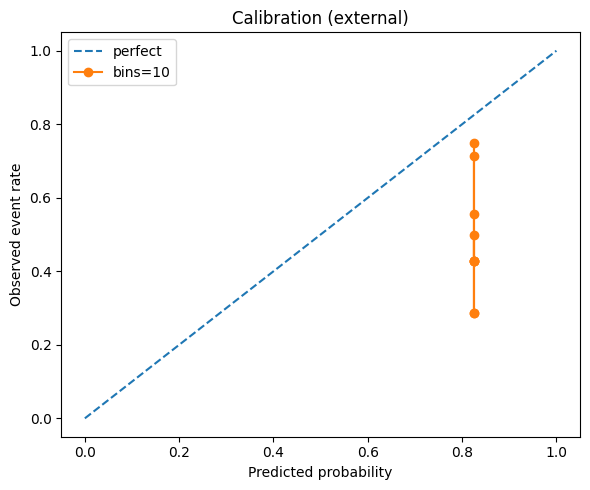

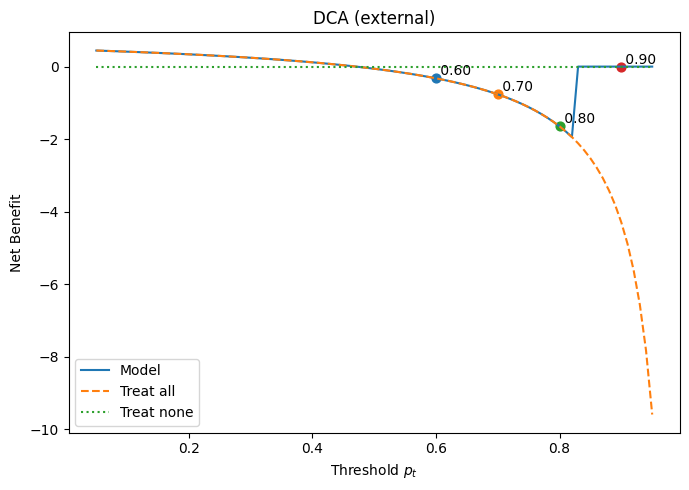

In [13]:
import os
import json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from joblib import dump, load

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, brier_score_loss, roc_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

# =======================
# KONFIGURATION
# =======================
CONFIG = {
    "target_col": "Verletzungsstatus",
    "normalize_headers": False,    # auf True setzen, wenn du Header robust normalisieren willst
    "ignore_cols": [],             # optional: z.B. IDs, die nicht in die Features dürfen

    # Nur noch SVC (kein Umschalter mehr)
    "svc": {
        "kernel": "rbf",
        "C": 1.0,
        "gamma": "scale",
        "class_weight": None,      # oder "balanced"
        "calibrate": True,         # True: CalibratedClassifierCV, False: SVC(probability=True)
        "calibration_method": "sigmoid",
        "calibration_cv": 5
    },

    "cv": {
        "splits": 5,
        "repeats": 10,
        "random_state": 42
    },
    "artifacts_prefix": "locked_slim"
}

# =======================
# Utility (optional Header-Normalizer)
# =======================
import re
def _norm_header(s: str) -> str:
    if s is None: return ""
    s = str(s)
    s = s.replace("\u00A0"," ").replace("\u2009"," ").replace("\u202F"," ").replace("\u2007"," ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def maybe_normalize_headers(df: pd.DataFrame) -> pd.DataFrame:
    if not CONFIG["normalize_headers"]:
        return df
    cols = [_norm_header(c) for c in df.columns]
    seen = {}
    out_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            out_cols.append(c)
        else:
            seen[c] += 1
            out_cols.append(f"{c}_dup{seen[c]}")
    df2 = df.copy()
    df2.columns = out_cols
    return df2

# =======================
# Calibration & DCA
# =======================
def compute_calibration(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

def decision_curve(y_true, y_prob, thresholds=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model, nb_all = [], []
    nb_none = np.zeros_like(thresholds)
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb_model.append((TP / N) - (FP / N) * weight)
        nb_all.append(prevalence - (1 - prevalence) * weight)
    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

def aggregate_calibration(cal_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    mats = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"]); fp = np.asarray(c["frac_pos"])
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        mats.append(interp)
    M = np.vstack(mats)
    briers = np.array([c["brier"] for c in cal_list if "brier" in c])
    return {
        "grid": grid,
        "mean_frac_pos": np.nanmean(M, axis=0),
        "std_frac_pos":  np.nanstd(M, axis=0),
        "brier_mean": float(np.mean(briers)) if len(briers) else np.nan,
        "brier_std":  float(np.std(briers))  if len(briers) else np.nan
    }

def aggregate_dca(dca_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    nb_m, nb_a, nb_n = [], [], []
    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m.append(np.interp(grid, th, np.asarray(d["nb_model"])))
        nb_a.append(np.interp(grid, th, np.asarray(d["nb_all"])))
        nb_n.append(np.interp(grid, th, np.asarray(d["nb_none"])))
    nb_m = np.vstack(nb_m); nb_a = np.vstack(nb_a); nb_n = np.vstack(nb_n)
    return {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_m, axis=0), "nb_model_std": np.std(nb_m, axis=0),
        "nb_all_mean":   np.mean(nb_a, axis=0), "nb_all_std":   np.std(nb_a, axis=0),
        "nb_none_mean":  np.mean(nb_n, axis=0), "nb_none_std":  np.std(nb_n, axis=0),
    }

def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]
    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit"); plt.ylabel("Beobachtete Positivrate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"]-dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"]+dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Schwelle $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# =======================
# Bootstrap-Intervalle & Kalibration
# =======================
def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

def bootstrap_ci_internal_oof(y, p, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    A,U,Bs = [],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
    pct = lambda v: (float(np.percentile(v,2.5)), float(np.percentile(v,97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs))}

def bootstrap_ci_thresholded(y, p, thr, B=2000, seed=42):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    def safe(f, yt, yp):
        try: return f(yt, yp)
        except Exception: return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return (accuracy_score(y_, yhat),
                safe(f1_score, y_, yhat),
                safe(precision_score, y_, yhat),
                safe(recall_score, y_, yhat))
    pt = metrics(y, p)
    ACC,F1,PR,RE = [],[],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        a,f,pr,re = metrics(y[s], p[s])
        ACC.append(a); F1.append(f); PR.append(pr); RE.append(re)
    pct = lambda v: (float(np.nanpercentile(v,2.5)), float(np.nanpercentile(v,97.5)))
    return {"Accuracy": (pt[0], pct(ACC)),
            "F1":       (pt[1], pct(F1)),
            "Precision":(pt[2], pct(PR)),
            "Recall":   (pt[3], pct(RE))}

from sklearn.linear_model import LogisticRegression as _LR  # nur für Kalibrations-Intercept/Slope
def _logit(p, eps=1e-8):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def calibration_intercept_slope(y, p):
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1,1)
    lr = _LR(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0,0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    return intercept, slope, brier

def expected_calibration_error(y, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

def bootstrap_ci_external(y, p, thr, B=2000, seed=42):
    import numpy as np
    from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                                 accuracy_score, f1_score, precision_score, recall_score)
    B = int(B)
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    def safe(f, yt, yp):
        try:
            return f(yt, yp)
        except Exception:
            return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        auroc = roc_auc_score(y_, p_)
        auprc = safe(average_precision_score, y_, p_)
        brier = brier_score_loss(y_, p_)
        acc   = accuracy_score(y_, yhat)
        f1    = safe(f1_score, y_, yhat)
        prec  = safe(precision_score, y_, yhat)
        rec   = safe(recall_score, y_, yhat)
        return auroc, auprc, brier, acc, f1, prec, rec
    pt = metrics(y, p)
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)
    A, U, Bs, Ac, F1, Pr, Re = [], [], [], [], [], [], []
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)
        a, u, b, ac, f, pr, re = metrics(y[s], p[s])
        A.append(a); U.append(u); Bs.append(b); Ac.append(ac); F1.append(f); Pr.append(pr); Re.append(re)
    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {
        "AUROC":    (pt[0], pct(A)),
        "AUPRC":    (pt[1], pct(U)),
        "Brier":    (pt[2], pct(Bs)),
        "Accuracy": (pt[3], pct(Ac)),
        "F1":       (pt[4], pct(F1)),
        "Precision":(pt[5], pct(Pr)),
        "Recall":   (pt[6], pct(Re)),
    }

def bootstrap_ci_calibration(y, p, B=2000, seed=42, n_bins=10):
    import numpy as np
    B = int(B); n_bins = int(n_bins)
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    def calib(y_, p_):
        I, S, Brier = calibration_intercept_slope(y_, p_)
        E = expected_calibration_error(y_, p_, n_bins=n_bins)
        return I, S, Brier, E
    I, S, Brier, E = calib(y, p)
    I_, S_, B_, E_ = [], [], [], []
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)
        i, s_, b, e = calib(y[s], p[s])
        I_.append(i); S_.append(s_); B_.append(b); E_.append(e)
    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {"Intercept": (I, pct(I_)),
            "Slope":     (S, pct(S_)),
            "Brier":     (Brier, pct(B_)),
            "ECE":       (E, pct(E_))}

# =======================
# SVC-Estimator (fix)
# =======================
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

def build_estimator():
    p = CONFIG["svc"]
    if p["calibrate"]:
        base = SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                   class_weight=p["class_weight"], probability=False)
        # NEU: estimator=...
        return CalibratedClassifierCV(estimator=base,
                                      method=p["calibration_method"],
                                      cv=p["calibration_cv"])
    else:
        return SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                   class_weight=p["class_weight"], probability=True)

# =======================
# CV-Pipeline
# =======================
def run_cv_pipeline(data_path, target_column="Verletzungsstatus",
                    cv_splits=5, cv_repeats=10, verbose=True):
    try:
        df = pd.read_excel(data_path, sheet_name=0)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    df = maybe_normalize_headers(df)
    if target_column not in df.columns:
        print(f"Target column '{target_column}' not in data.")
        return None

    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column] + CONFIG["ignore_cols"], errors="ignore").copy()

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        try:
            print(f"Class distribution: {y.value_counts().to_dict()}")
        except Exception:
            pass

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats,
                                 random_state=CONFIG["cv"]["random_state"])

    metrics_results, cal_list, dca_list = [], [], []

    oof_true  = y.to_numpy().astype(int)
    oof_pred  = np.zeros(len(X), dtype=float)
    oof_sum   = np.zeros(len(X), dtype=float)
    oof_count = np.zeros(len(X), dtype=int)

    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose:
            print(f"\n--- Fold {fold} ---")
        X_train, y_train = X.iloc[tr].copy(), y.iloc[tr].copy()
        X_test,  y_test  = X.iloc[te].copy(), y.iloc[te].copy()

        scaler = MinMaxScaler()
        X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
        X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

        est = build_estimator()
        est.fit(X_train_sc, y_train)

        # Vorhersagen (Probas)
        if hasattr(est, "predict_proba"):
            y_pred_prob = est.predict_proba(X_test_sc)[:,1]
            y_train_prob = est.predict_proba(X_train_sc)[:,1]
        else:
            from scipy.special import expit
            y_pred_prob = expit(est.decision_function(X_test_sc))
            y_train_prob = expit(est.decision_function(X_train_sc))

        oof_sum[te]   += y_pred_prob
        oof_count[te] += 1

        # temporäre binäre 0.5-Schwelle (nur für Fold-Reporting)
        y_pred = (y_pred_prob >= 0.5).astype(int)
        train_pred = (y_train_prob >= 0.5).astype(int)

        fold_metrics = {
            'train_accuracy': accuracy_score(y_train, train_pred),
            'test_accuracy':  accuracy_score(y_test, y_pred),
            'f1_score':       f1_score(y_test, y_pred, zero_division=0),
            'precision':      precision_score(y_test, y_pred, zero_division=0),
            'recall':         recall_score(y_test, y_pred, zero_division=0),
            'roc_auc':        roc_auc_score(y_test, y_pred_prob),
        }
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        fold_metrics['brier_score'] = cal["brier"]
        cal_list.append(cal)

        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05,0.95,91))
        dca_list.append(dca)

        metrics_results.append(fold_metrics)

    # OOF mitteln
    mask = oof_count > 0
    oof_pred[mask] = oof_sum[mask] / oof_count[mask]

    # Aggregierte Tables
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg, (oof_true, oof_pred, df, X.columns.tolist())

# =======================
# Youden & Freezing
# =======================
def determine_fixed_threshold_youden(oof_true, oof_pred):
    fpr, tpr, thr = roc_curve(oof_true, oof_pred)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def freeze_pipeline_for_external(df, feature_order, fixed_threshold, save_prefix="locked_slim"):
    y_all = df[CONFIG["target_col"]].astype(int).to_numpy()
    X_all = df.drop(columns=[CONFIG["target_col"]] + CONFIG["ignore_cols"], errors="ignore").copy()
    X_all = X_all[feature_order].copy()  # exakt gleiche Spaltenreihenfolge

    scaler = MinMaxScaler()
    X_all_sc = pd.DataFrame(scaler.fit_transform(X_all), columns=feature_order)

    est = build_estimator()
    est.fit(X_all_sc, y_all)

    dump(est, f"{save_prefix}_model.joblib")
    dump(scaler, f"{save_prefix}_scaler.joblib")
    dump(feature_order, f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json", "w") as f:
        json.dump({"fixed_threshold": float(fixed_threshold),
                   "target_col": CONFIG["target_col"],
                   "model_name": "svc"}, f)

# =======================
# Externe Validierung
# =======================
def plot_calibration_single(y, p, n_bins=10, title="Calibration (external)"):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(6,5))
    plt.plot([0,1], [0,1], '--', label="perfect")
    plt.plot(mean_pred, frac_pos, marker='o', label=f"bins={n_bins}")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed event rate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_single(dca, mark_pts=None, title="DCA (external)"):
    th = dca["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca["nb_model"], label="Model")
    plt.plot(th, dca["nb_all"], '--', label="Treat all")
    plt.plot(th, dca["nb_none"], ':', label="Treat none")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca["nb_model"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def external_validate_locked(external_path, save_prefix="locked_slim",
                             n_bins=10, dca_marks=[0.60,0.70,0.80,0.90]):
    est   = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr = float(meta["fixed_threshold"]); target_col = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)

    X_ext = df_ext[feature_order].copy()   # identische Spaltenreihenfolge
    y_ext = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        from scipy.special import expit
        p_ext = expit(est.decision_function(X_ext_sc))

    stats = bootstrap_ci_external(y_ext, p_ext, thr, B=2000)
    print_ci_block("External performance 95% CIs (Bootstrap)", stats)

    I,S,B = calibration_intercept_slope(y_ext, p_ext)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")

    cal_ci = bootstrap_ci_calibration(y_ext, p_ext, B=2000, n_bins=n_bins)
    print_ci_block("External calibration 95% CIs (Bootstrap)", cal_ci)
    plot_calibration_single(y_ext, p_ext, n_bins=n_bins, title="Calibration (external)")

    dca = decision_curve(y_ext, p_ext, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title="DCA (external)")

# =======================
# MAIN
# =======================
def main():
    # ==== PFADE ANPASSEN ====
    INTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Maestroni_ML_matched.xlsx"
    EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Motum_ML_matched.xlsx"
    # ========================

    res = run_cv_pipeline(
        INTERNAL_PATH,
        target_column=CONFIG["target_col"],
        cv_splits=CONFIG["cv"]["splits"],
        cv_repeats=CONFIG["cv"]["repeats"],
        verbose=True
    )
    if res is None:
        print("Pipeline failed."); return
    aggregated_results, cal_agg, dca_agg, (oof_true, oof_pred, df_all, feature_order) = res

    print("\n=== Model Performance Summary (CV folds) ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60,0.70,0.80,0.90], title="DCA (Test, mean ± SD)")

    oof_ci = bootstrap_ci_internal_oof(oof_true, oof_pred, B=2000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    fixed_threshold = determine_fixed_threshold_youden(oof_true, oof_pred)
    print(f"\nFixed threshold (Youden on OOF): {fixed_threshold:.3f}")

    th_ci = bootstrap_ci_thresholded(oof_true, oof_pred, thr=fixed_threshold, B=2000)
    print_ci_block(f"Internal thresholded metrics at t={fixed_threshold:.2f} (Bootstrap 95% CIs)", th_ci)

    # Freeze Artefakte
    freeze_pipeline_for_external(df_all, feature_order, fixed_threshold, save_prefix=CONFIG["artifacts_prefix"])

    # Externe Validierung
    if os.path.exists(EXTERNAL_PATH):
        external_validate_locked(EXTERNAL_PATH, save_prefix=CONFIG["artifacts_prefix"],
                                 n_bins=10, dca_marks=[0.60,0.70,0.80,0.90])
    else:
        print(f"\n[Hint] External validation file not found:\n{EXTERNAL_PATH}\n"
              f"→ Set EXTERNAL_PATH to your file and re-run.")

if __name__ == "__main__":
    main()


### SVC Nachkalibrieren (Motum extern)


=== External Calibration: BEFORE vs AFTER recalibration (SVC) ===
Before  -> CITL: -0.119 | Slope: 0.001 | Brier: 0.375
After   -> CITL: -0.118 | Slope: 0.000 | Brier: 0.249  (Platt (logistic))

=== Thresholded metrics at INTERNAL threshold t=0.51 ===

Before recalibration
AUROC: 0.610 (0.477–0.745)
AUPRC: 0.619 (0.509–0.753)
Brier: 0.375 (0.375–0.375)
Accuracy: 0.471 (0.471–0.471)
F1: 0.640 (0.640–0.640)
Precision: 0.471 (0.471–0.471)
Recall: 1.000 (1.000–1.000)

After recalibration (Platt (logistic))
AUROC: 0.604 (0.471–0.734)
AUPRC: 0.603 (0.497–0.731)
Brier: 0.249 (0.249–0.249)
Accuracy: 0.529 (0.529–0.529)
F1: 0.000 (0.000–0.000)
Precision: 0.000 (0.000–0.000)
Recall: 0.000 (0.000–0.000)

=== Thresholded metrics at EXTERNAL Youden threshold t=0.47 (on recalibrated p) ===

After recalibration + external Youden (Platt (logistic))
AUROC: 0.604 (0.471–0.734)
AUPRC: 0.603 (0.497–0.731)
Brier: 0.249 (0.249–0.249)
Accuracy: 0.603 (0.485–0.721)
F1: 0.571 (0.421–0.698)
Precision: 0.581 (0

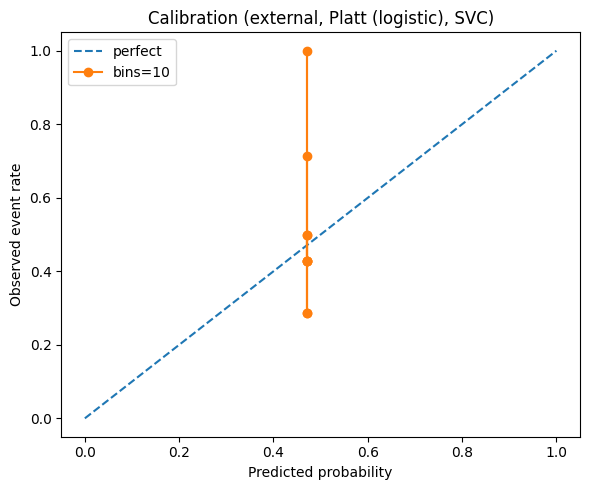

[Plot] DCA (recalibrated, SVC)


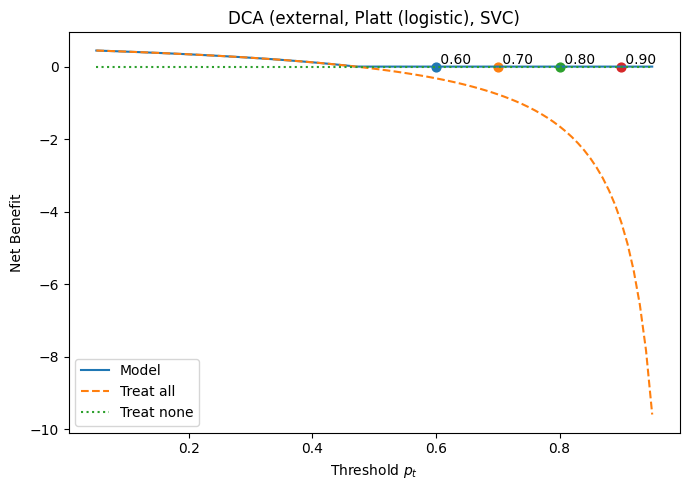

In [14]:
# === Recalibration block: run in a new cell AFTER your freeze + external_validate_locked ===
from sklearn.svm import SVC
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from scipy.special import expit

def _is_svc_like(est):
    # Erlaube SVC direkt oder CalibratedClassifierCV mit SVC-Estimator
    if isinstance(est, SVC):
        return True
    if isinstance(est, CalibratedClassifierCV):
        base = getattr(est, "estimator", None)  # neuer sklearn-Name
        if base is None:
            base = getattr(est, "base_estimator", None)  # fallback für ältere Versionen
        return isinstance(base, SVC)
    return False

def _predict_proba_svc_like(est, X):
    # Liefert P(y=1) auch für ungecalibrierte SVCs via decision_function→sigmoid
    if hasattr(est, "predict_proba"):
        return est.predict_proba(X)[:, 1]
    # z.B. ungecalibrierter SVC(probability=False): decision_function vorhanden
    return expit(est.decision_function(X))

def recalibrate_external_svc(external_path,
                             save_prefix="locked_slim",
                             method="platt",               # "platt" oder "isotonic"
                             also_compute_external_youden=True,
                             n_bins=10,
                             dca_marks=[0.60,0.70,0.80,0.90]):
    """
    Post-hoc Re-Kalibration NUR für SVC-Modelle.
    Erwartet Freeze-Artefakte (Model, Scaler, Feature-Order, Meta).
    Greift das Modell NICHT an, kalibriert nur die externen p.
    """
    # --- Artefakte & Daten laden (wie in external_validate_locked) ---
    est    = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr_internal = float(meta["fixed_threshold"])
    target_col   = meta["target_col"]

    # Safety: nur SVC zulassen
    if not _is_svc_like(est):
        raise TypeError("Dieses Recalibration-Notebook ist nur für SVC-Modelle gedacht (SVC oder CalibratedClassifierCV(SVC)).")

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)
    X_ext  = df_ext[feature_order].copy()
    y_ext  = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)

    # Roh-Wahrscheinlichkeiten vom (SVC-)Modell
    p_ext = _predict_proba_svc_like(est, X_ext_sc)

    # --- Re-Kalibration ---
    if method.lower() == "platt":
        # Platt scaling: Logistische Regression auf logit(p) ~ y
        z = _logit(p_ext)[:, None]
        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(z, y_ext)
        p_ext_cal = lr.predict_proba(z)[:, 1]
        cal_label = "Platt (logistic)"
    elif method.lower() == "isotonic":
        iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
        p_ext_cal = iso.fit_transform(p_ext, y_ext)
        cal_label = "Isotonic"
    else:
        raise ValueError("method must be 'platt' or 'isotonic'.")

    # --- Reporting: Kalibration vor/nach ---
    print("\n=== External Calibration: BEFORE vs AFTER recalibration (SVC) ===")
    I0,S0,B0 = calibration_intercept_slope(y_ext, p_ext)
    I1,S1,B1 = calibration_intercept_slope(y_ext, p_ext_cal)
    print(f"Before  -> CITL: {I0:.3f} | Slope: {S0:.3f} | Brier: {B0:.3f}")
    print(f"After   -> CITL: {I1:.3f} | Slope: {S1:.3f} | Brier: {B1:.3f}  ({cal_label})")

    # --- Schwellenabhängige Metriken mit interner Schwelle (fairer Vergleich) ---
    print(f"\n=== Thresholded metrics at INTERNAL threshold t={thr_internal:.2f} ===")
    stats_thr_int_before = bootstrap_ci_external(y_ext, p_ext,     thr_internal, B=2000)
    stats_thr_int_after  = bootstrap_ci_external(y_ext, p_ext_cal, thr_internal, B=2000)
    print_ci_block("Before recalibration", stats_thr_int_before)
    print_ci_block(f"After recalibration ({cal_label})", stats_thr_int_after)

    # --- Optional: neue externe Youden-Schwelle auf rekalibrierten p ---
    thr_ext = None
    if also_compute_external_youden:
        thr_ext = determine_fixed_threshold_youden(y_ext, p_ext_cal)
        print(f"\n=== Thresholded metrics at EXTERNAL Youden threshold t={thr_ext:.2f} (on recalibrated p) ===")
        stats_thr_ext = bootstrap_ci_external(y_ext, p_ext_cal, thr_ext, B=2000)
        print_ci_block(f"After recalibration + external Youden ({cal_label})", stats_thr_ext)

    # --- Kalibrations- und DCA-Plots (nach Re-Kalibration) ---
    print("\n[Plot] Calibration curve (recalibrated, SVC)")
    plot_calibration_single(y_ext, p_ext_cal, n_bins=n_bins,
                            title=f"Calibration (external, {cal_label}, SVC)")

    print("[Plot] DCA (recalibrated, SVC)")
    dca = decision_curve(y_ext, p_ext_cal, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title=f"DCA (external, {cal_label}, SVC)")

    return {
        "p_ext_raw": p_ext,
        "p_ext_cal": p_ext_cal,
        "thr_internal": thr_internal,
        "thr_external_youden": thr_ext
    }

# Aufruf (Pfad anpassen):
_ = recalibrate_external_svc(
        external_path=r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Motum_ML_matched.xlsx",
        save_prefix=CONFIG["artifacts_prefix"],
        method="platt",                    # oder "isotonic"
        also_compute_external_youden=True,
        n_bins=10
    )


### Externe Validierung (SVC) - Maestroni intern und Motum extern

Data loaded: 68 samples, 25 features
Class distribution: {0: 36, 1: 32}

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---

--- Fold 6 ---

--- Fold 7 ---

--- Fold 8 ---

--- Fold 9 ---

--- Fold 10 ---

--- Fold 11 ---

--- Fold 12 ---

--- Fold 13 ---

--- Fold 14 ---

--- Fold 15 ---

--- Fold 16 ---

--- Fold 17 ---

--- Fold 18 ---

--- Fold 19 ---

--- Fold 20 ---

--- Fold 21 ---

--- Fold 22 ---

--- Fold 23 ---

--- Fold 24 ---

--- Fold 25 ---

--- Fold 26 ---

--- Fold 27 ---

--- Fold 28 ---

--- Fold 29 ---

--- Fold 30 ---

--- Fold 31 ---

--- Fold 32 ---

--- Fold 33 ---

--- Fold 34 ---

--- Fold 35 ---

--- Fold 36 ---

--- Fold 37 ---

--- Fold 38 ---

--- Fold 39 ---

--- Fold 40 ---

--- Fold 41 ---

--- Fold 42 ---

--- Fold 43 ---

--- Fold 44 ---

--- Fold 45 ---

--- Fold 46 ---

--- Fold 47 ---

--- Fold 48 ---

--- Fold 49 ---

--- Fold 50 ---

=== Model Performance Summary (CV folds) ===
Metric          Mean                 Std 

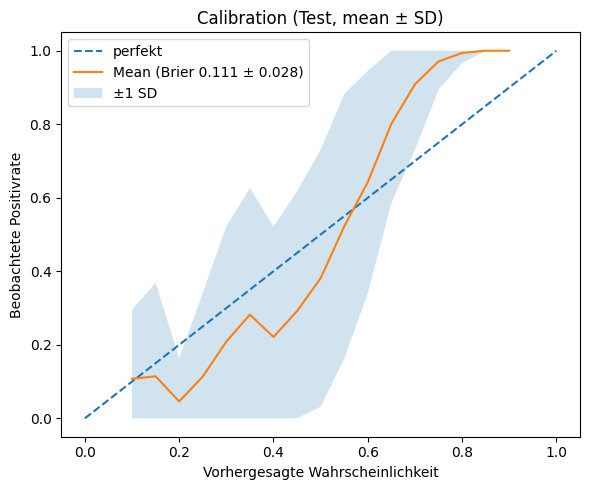

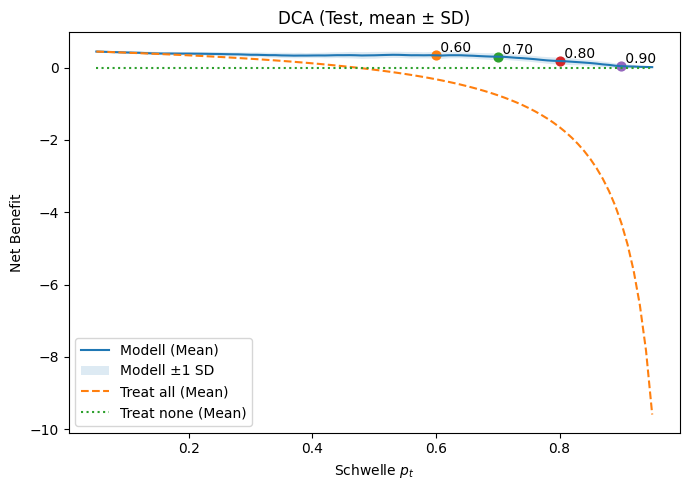


Internal OOF 95% CIs (Bootstrap)
AUROC: 0.939 (0.865–0.988)
AUPRC: 0.952 (0.891–0.989)
Brier: 0.109 (0.080–0.146)

Fixed threshold (Youden on OOF): 0.505

Internal thresholded metrics at t=0.50 (Bootstrap 95% CIs)
Accuracy: 0.897 (0.809–0.956)
F1: 0.889 (0.791–0.960)
Precision: 0.903 (0.786–1.000)
Recall: 0.875 (0.742–0.971)

External performance 95% CIs (Bootstrap)
AUROC: 0.500 (0.500–0.500)
AUPRC: 0.533 (0.533–0.533)
Brier: 0.343 (0.343–0.343)
Accuracy: 0.533 (0.533–0.533)
F1: 0.696 (0.696–0.696)
Precision: 0.533 (0.533–0.533)
Recall: 1.000 (1.000–1.000)

Calibration (point estimates):
  Intercept (CITL): 0.134
  Slope:            -0.000
  Brier:            0.343

External calibration 95% CIs (Bootstrap)
Intercept: 0.134 (0.134–0.134)
Slope: -0.000 (-0.000–-0.000)
Brier: 0.343 (0.343–0.343)
ECE: 0.306 (0.306–0.306)


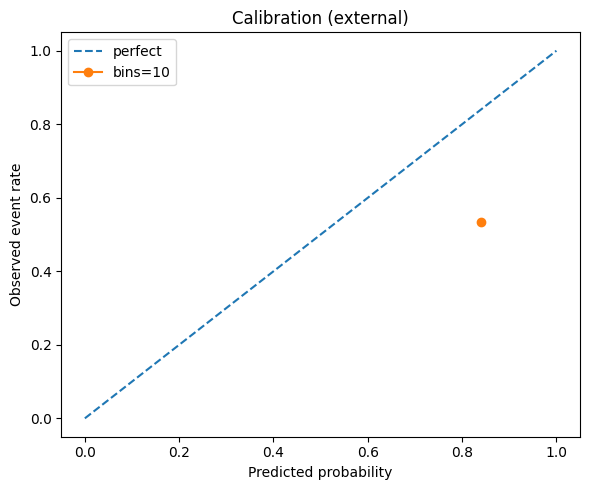

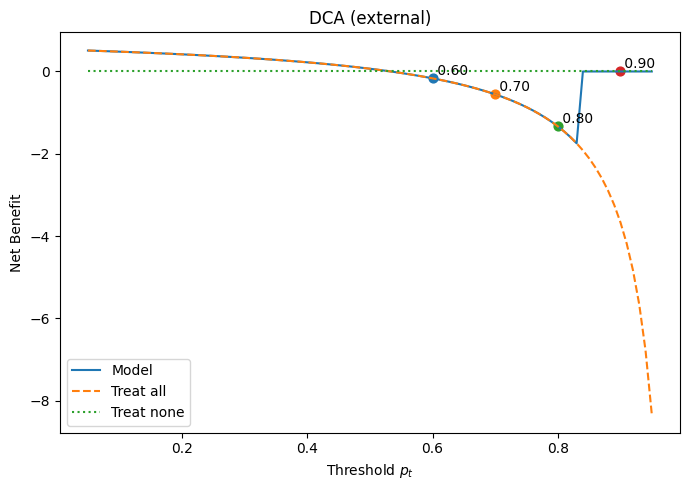

In [15]:
import os
import json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from joblib import dump, load

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, brier_score_loss, roc_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

# =======================
# KONFIGURATION
# =======================
CONFIG = {
    "target_col": "Verletzungsstatus",
    "normalize_headers": False,    # auf True setzen, wenn du Header robust normalisieren willst
    "ignore_cols": [],             # optional: z.B. IDs, die nicht in die Features dürfen

    # Nur noch SVC (kein Umschalter mehr)
    "svc": {
        "kernel": "rbf",
        "C": 1.0,
        "gamma": "scale",
        "class_weight": None,      # oder "balanced"
        "calibrate": True,         # True: CalibratedClassifierCV, False: SVC(probability=True)
        "calibration_method": "sigmoid",
        "calibration_cv": 5
    },

    "cv": {
        "splits": 5,
        "repeats": 10,
        "random_state": 42
    },
    "artifacts_prefix": "locked_slim"
}

# =======================
# Utility (optional Header-Normalizer)
# =======================
import re
def _norm_header(s: str) -> str:
    if s is None: return ""
    s = str(s)
    s = s.replace("\u00A0"," ").replace("\u2009"," ").replace("\u202F"," ").replace("\u2007"," ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def maybe_normalize_headers(df: pd.DataFrame) -> pd.DataFrame:
    if not CONFIG["normalize_headers"]:
        return df
    cols = [_norm_header(c) for c in df.columns]
    seen = {}
    out_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            out_cols.append(c)
        else:
            seen[c] += 1
            out_cols.append(f"{c}_dup{seen[c]}")
    df2 = df.copy()
    df2.columns = out_cols
    return df2

# =======================
# Calibration & DCA
# =======================
def compute_calibration(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

def decision_curve(y_true, y_prob, thresholds=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model, nb_all = [], []
    nb_none = np.zeros_like(thresholds)
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb_model.append((TP / N) - (FP / N) * weight)
        nb_all.append(prevalence - (1 - prevalence) * weight)
    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

def aggregate_calibration(cal_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    mats = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"]); fp = np.asarray(c["frac_pos"])
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        mats.append(interp)
    M = np.vstack(mats)
    briers = np.array([c["brier"] for c in cal_list if "brier" in c])
    return {
        "grid": grid,
        "mean_frac_pos": np.nanmean(M, axis=0),
        "std_frac_pos":  np.nanstd(M, axis=0),
        "brier_mean": float(np.mean(briers)) if len(briers) else np.nan,
        "brier_std":  float(np.std(briers))  if len(briers) else np.nan
    }

def aggregate_dca(dca_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    nb_m, nb_a, nb_n = [], [], []
    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m.append(np.interp(grid, th, np.asarray(d["nb_model"])))
        nb_a.append(np.interp(grid, th, np.asarray(d["nb_all"])))
        nb_n.append(np.interp(grid, th, np.asarray(d["nb_none"])))
    nb_m = np.vstack(nb_m); nb_a = np.vstack(nb_a); nb_n = np.vstack(nb_n)
    return {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_m, axis=0), "nb_model_std": np.std(nb_m, axis=0),
        "nb_all_mean":   np.mean(nb_a, axis=0), "nb_all_std":   np.std(nb_a, axis=0),
        "nb_none_mean":  np.mean(nb_n, axis=0), "nb_none_std":  np.std(nb_n, axis=0),
    }

def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]
    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit"); plt.ylabel("Beobachtete Positivrate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"]-dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"]+dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Schwelle $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# =======================
# Bootstrap-Intervalle & Kalibration
# =======================
def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

def bootstrap_ci_internal_oof(y, p, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    A,U,Bs = [],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
    pct = lambda v: (float(np.percentile(v,2.5)), float(np.percentile(v,97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs))}

def bootstrap_ci_thresholded(y, p, thr, B=2000, seed=42):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    def safe(f, yt, yp):
        try: return f(yt, yp)
        except Exception: return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return (accuracy_score(y_, yhat),
                safe(f1_score, y_, yhat),
                safe(precision_score, y_, yhat),
                safe(recall_score, y_, yhat))
    pt = metrics(y, p)
    ACC,F1,PR,RE = [],[],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        a,f,pr,re = metrics(y[s], p[s])
        ACC.append(a); F1.append(f); PR.append(pr); RE.append(re)
    pct = lambda v: (float(np.nanpercentile(v,2.5)), float(np.nanpercentile(v,97.5)))
    return {"Accuracy": (pt[0], pct(ACC)),
            "F1":       (pt[1], pct(F1)),
            "Precision":(pt[2], pct(PR)),
            "Recall":   (pt[3], pct(RE))}

from sklearn.linear_model import LogisticRegression as _LR  # nur für Kalibrations-Intercept/Slope
def _logit(p, eps=1e-8):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def calibration_intercept_slope(y, p):
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1,1)
    lr = _LR(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0,0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    return intercept, slope, brier

def expected_calibration_error(y, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

def bootstrap_ci_external(y, p, thr, B=2000, seed=42):
    import numpy as np
    from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                                 accuracy_score, f1_score, precision_score, recall_score)
    B = int(B)
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    def safe(f, yt, yp):
        try:
            return f(yt, yp)
        except Exception:
            return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        auroc = roc_auc_score(y_, p_)
        auprc = safe(average_precision_score, y_, p_)
        brier = brier_score_loss(y_, p_)
        acc   = accuracy_score(y_, yhat)
        f1    = safe(f1_score, y_, yhat)
        prec  = safe(precision_score, y_, yhat)
        rec   = safe(recall_score, y_, yhat)
        return auroc, auprc, brier, acc, f1, prec, rec
    pt = metrics(y, p)
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)
    A, U, Bs, Ac, F1, Pr, Re = [], [], [], [], [], [], []
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)
        a, u, b, ac, f, pr, re = metrics(y[s], p[s])
        A.append(a); U.append(u); Bs.append(b); Ac.append(ac); F1.append(f); Pr.append(pr); Re.append(re)
    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {
        "AUROC":    (pt[0], pct(A)),
        "AUPRC":    (pt[1], pct(U)),
        "Brier":    (pt[2], pct(Bs)),
        "Accuracy": (pt[3], pct(Ac)),
        "F1":       (pt[4], pct(F1)),
        "Precision":(pt[5], pct(Pr)),
        "Recall":   (pt[6], pct(Re)),
    }

def bootstrap_ci_calibration(y, p, B=2000, seed=42, n_bins=10):
    import numpy as np
    B = int(B); n_bins = int(n_bins)
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    def calib(y_, p_):
        I, S, Brier = calibration_intercept_slope(y_, p_)
        E = expected_calibration_error(y_, p_, n_bins=n_bins)
        return I, S, Brier, E
    I, S, Brier, E = calib(y, p)
    I_, S_, B_, E_ = [], [], [], []
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)
        i, s_, b, e = calib(y[s], p[s])
        I_.append(i); S_.append(s_); B_.append(b); E_.append(e)
    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {"Intercept": (I, pct(I_)),
            "Slope":     (S, pct(S_)),
            "Brier":     (Brier, pct(B_)),
            "ECE":       (E, pct(E_))}

# =======================
# SVC-Estimator (fix)
# =======================
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

def build_estimator():
    p = CONFIG["svc"]
    if p["calibrate"]:
        base = SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                   class_weight=p["class_weight"], probability=False)
        # NEU: estimator=...
        return CalibratedClassifierCV(estimator=base,
                                      method=p["calibration_method"],
                                      cv=p["calibration_cv"])
    else:
        return SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                   class_weight=p["class_weight"], probability=True)

# =======================
# CV-Pipeline
# =======================
def run_cv_pipeline(data_path, target_column="Verletzungsstatus",
                    cv_splits=5, cv_repeats=10, verbose=True):
    try:
        df = pd.read_excel(data_path, sheet_name=0)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    df = maybe_normalize_headers(df)
    if target_column not in df.columns:
        print(f"Target column '{target_column}' not in data.")
        return None

    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column] + CONFIG["ignore_cols"], errors="ignore").copy()

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        try:
            print(f"Class distribution: {y.value_counts().to_dict()}")
        except Exception:
            pass

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats,
                                 random_state=CONFIG["cv"]["random_state"])

    metrics_results, cal_list, dca_list = [], [], []

    oof_true  = y.to_numpy().astype(int)
    oof_pred  = np.zeros(len(X), dtype=float)
    oof_sum   = np.zeros(len(X), dtype=float)
    oof_count = np.zeros(len(X), dtype=int)

    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose:
            print(f"\n--- Fold {fold} ---")
        X_train, y_train = X.iloc[tr].copy(), y.iloc[tr].copy()
        X_test,  y_test  = X.iloc[te].copy(), y.iloc[te].copy()

        scaler = MinMaxScaler()
        X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
        X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

        est = build_estimator()
        est.fit(X_train_sc, y_train)

        # Vorhersagen (Probas)
        if hasattr(est, "predict_proba"):
            y_pred_prob = est.predict_proba(X_test_sc)[:,1]
            y_train_prob = est.predict_proba(X_train_sc)[:,1]
        else:
            from scipy.special import expit
            y_pred_prob = expit(est.decision_function(X_test_sc))
            y_train_prob = expit(est.decision_function(X_train_sc))

        oof_sum[te]   += y_pred_prob
        oof_count[te] += 1

        # temporäre binäre 0.5-Schwelle (nur für Fold-Reporting)
        y_pred = (y_pred_prob >= 0.5).astype(int)
        train_pred = (y_train_prob >= 0.5).astype(int)

        fold_metrics = {
            'train_accuracy': accuracy_score(y_train, train_pred),
            'test_accuracy':  accuracy_score(y_test, y_pred),
            'f1_score':       f1_score(y_test, y_pred, zero_division=0),
            'precision':      precision_score(y_test, y_pred, zero_division=0),
            'recall':         recall_score(y_test, y_pred, zero_division=0),
            'roc_auc':        roc_auc_score(y_test, y_pred_prob),
        }
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        fold_metrics['brier_score'] = cal["brier"]
        cal_list.append(cal)

        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05,0.95,91))
        dca_list.append(dca)

        metrics_results.append(fold_metrics)

    # OOF mitteln
    mask = oof_count > 0
    oof_pred[mask] = oof_sum[mask] / oof_count[mask]

    # Aggregierte Tables
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg, (oof_true, oof_pred, df, X.columns.tolist())

# =======================
# Youden & Freezing
# =======================
def determine_fixed_threshold_youden(oof_true, oof_pred):
    fpr, tpr, thr = roc_curve(oof_true, oof_pred)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def freeze_pipeline_for_external(df, feature_order, fixed_threshold, save_prefix="locked_slim"):
    y_all = df[CONFIG["target_col"]].astype(int).to_numpy()
    X_all = df.drop(columns=[CONFIG["target_col"]] + CONFIG["ignore_cols"], errors="ignore").copy()
    X_all = X_all[feature_order].copy()  # exakt gleiche Spaltenreihenfolge

    scaler = MinMaxScaler()
    X_all_sc = pd.DataFrame(scaler.fit_transform(X_all), columns=feature_order)

    est = build_estimator()
    est.fit(X_all_sc, y_all)

    dump(est, f"{save_prefix}_model.joblib")
    dump(scaler, f"{save_prefix}_scaler.joblib")
    dump(feature_order, f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json", "w") as f:
        json.dump({"fixed_threshold": float(fixed_threshold),
                   "target_col": CONFIG["target_col"],
                   "model_name": "svc"}, f)

# =======================
# Externe Validierung
# =======================
def plot_calibration_single(y, p, n_bins=10, title="Calibration (external)"):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(6,5))
    plt.plot([0,1], [0,1], '--', label="perfect")
    plt.plot(mean_pred, frac_pos, marker='o', label=f"bins={n_bins}")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed event rate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_single(dca, mark_pts=None, title="DCA (external)"):
    th = dca["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca["nb_model"], label="Model")
    plt.plot(th, dca["nb_all"], '--', label="Treat all")
    plt.plot(th, dca["nb_none"], ':', label="Treat none")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca["nb_model"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def external_validate_locked(external_path, save_prefix="locked_slim",
                             n_bins=10, dca_marks=[0.60,0.70,0.80,0.90]):
    est   = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr = float(meta["fixed_threshold"]); target_col = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)

    X_ext = df_ext[feature_order].copy()   # identische Spaltenreihenfolge
    y_ext = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        from scipy.special import expit
        p_ext = expit(est.decision_function(X_ext_sc))

    stats = bootstrap_ci_external(y_ext, p_ext, thr, B=2000)
    print_ci_block("External performance 95% CIs (Bootstrap)", stats)

    I,S,B = calibration_intercept_slope(y_ext, p_ext)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")

    cal_ci = bootstrap_ci_calibration(y_ext, p_ext, B=2000, n_bins=n_bins)
    print_ci_block("External calibration 95% CIs (Bootstrap)", cal_ci)
    plot_calibration_single(y_ext, p_ext, n_bins=n_bins, title="Calibration (external)")

    dca = decision_curve(y_ext, p_ext, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title="DCA (external)")

# =======================
# MAIN
# =======================
def main():
    # ==== PFADE ANPASSEN ====
    INTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Motum_ML_matched.xlsx"
    EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Maestroni_ML_matched.xlsx"
    # ========================

    res = run_cv_pipeline(
        INTERNAL_PATH,
        target_column=CONFIG["target_col"],
        cv_splits=CONFIG["cv"]["splits"],
        cv_repeats=CONFIG["cv"]["repeats"],
        verbose=True
    )
    if res is None:
        print("Pipeline failed."); return
    aggregated_results, cal_agg, dca_agg, (oof_true, oof_pred, df_all, feature_order) = res

    print("\n=== Model Performance Summary (CV folds) ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60,0.70,0.80,0.90], title="DCA (Test, mean ± SD)")

    oof_ci = bootstrap_ci_internal_oof(oof_true, oof_pred, B=2000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    fixed_threshold = determine_fixed_threshold_youden(oof_true, oof_pred)
    print(f"\nFixed threshold (Youden on OOF): {fixed_threshold:.3f}")

    th_ci = bootstrap_ci_thresholded(oof_true, oof_pred, thr=fixed_threshold, B=2000)
    print_ci_block(f"Internal thresholded metrics at t={fixed_threshold:.2f} (Bootstrap 95% CIs)", th_ci)

    # Freeze Artefakte
    freeze_pipeline_for_external(df_all, feature_order, fixed_threshold, save_prefix=CONFIG["artifacts_prefix"])

    # Externe Validierung
    if os.path.exists(EXTERNAL_PATH):
        external_validate_locked(EXTERNAL_PATH, save_prefix=CONFIG["artifacts_prefix"],
                                 n_bins=10, dca_marks=[0.60,0.70,0.80,0.90])
    else:
        print(f"\n[Hint] External validation file not found:\n{EXTERNAL_PATH}\n"
              f"→ Set EXTERNAL_PATH to your file and re-run.")

if __name__ == "__main__":
    main()


#### SVC Nachkalibrieren (Maestroni extern)


=== External Calibration: BEFORE vs AFTER recalibration (SVC) ===
Before  -> CITL: 0.134 | Slope: -0.000 | Brier: 0.343
After   -> CITL: 0.134 | Slope: -0.000 | Brier: 0.249  (Platt (logistic))

=== Thresholded metrics at INTERNAL threshold t=0.50 ===

Before recalibration
AUROC: 0.500 (0.500–0.500)
AUPRC: 0.533 (0.533–0.533)
Brier: 0.343 (0.343–0.343)
Accuracy: 0.533 (0.533–0.533)
F1: 0.696 (0.696–0.696)
Precision: 0.533 (0.533–0.533)
Recall: 1.000 (1.000–1.000)

After recalibration (Platt (logistic))
AUROC: 0.500 (0.500–0.500)
AUPRC: 0.533 (0.533–0.533)
Brier: 0.249 (0.249–0.249)
Accuracy: 0.533 (0.533–0.533)
F1: 0.696 (0.696–0.696)
Precision: 0.533 (0.533–0.533)
Recall: 1.000 (1.000–1.000)

=== Thresholded metrics at EXTERNAL Youden threshold t=inf (on recalibrated p) ===

After recalibration + external Youden (Platt (logistic))
AUROC: 0.500 (0.500–0.500)
AUPRC: 0.533 (0.533–0.533)
Brier: 0.249 (0.249–0.249)
Accuracy: 0.467 (0.467–0.467)
F1: 0.000 (0.000–0.000)
Precision: 0.000 (0.

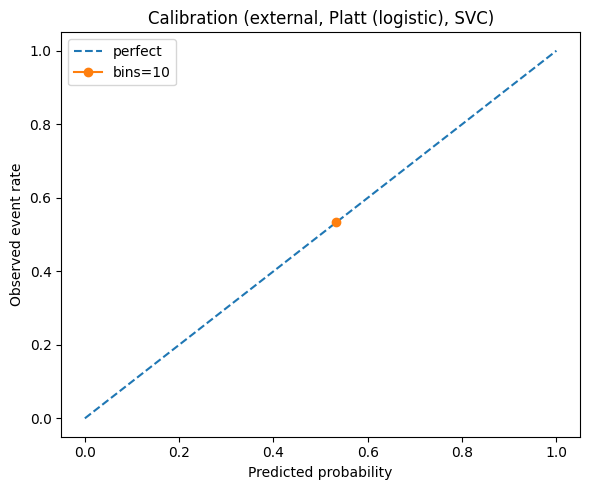

[Plot] DCA (recalibrated, SVC)


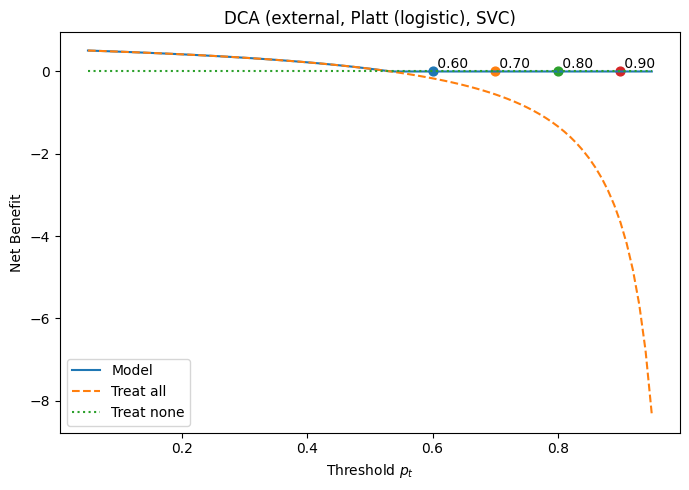

In [16]:
# === Recalibration block: run in a new cell AFTER your freeze + external_validate_locked ===
from sklearn.svm import SVC
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from scipy.special import expit

def _is_svc_like(est):
    # Erlaube SVC direkt oder CalibratedClassifierCV mit SVC-Estimator
    if isinstance(est, SVC):
        return True
    if isinstance(est, CalibratedClassifierCV):
        base = getattr(est, "estimator", None)  # neuer sklearn-Name
        if base is None:
            base = getattr(est, "base_estimator", None)  # fallback für ältere Versionen
        return isinstance(base, SVC)
    return False

def _predict_proba_svc_like(est, X):
    # Liefert P(y=1) auch für ungecalibrierte SVCs via decision_function→sigmoid
    if hasattr(est, "predict_proba"):
        return est.predict_proba(X)[:, 1]
    # z.B. ungecalibrierter SVC(probability=False): decision_function vorhanden
    return expit(est.decision_function(X))

def recalibrate_external_svc(external_path,
                             save_prefix="locked_slim",
                             method="platt",               # "platt" oder "isotonic"
                             also_compute_external_youden=True,
                             n_bins=10,
                             dca_marks=[0.60,0.70,0.80,0.90]):
    """
    Post-hoc Re-Kalibration NUR für SVC-Modelle.
    Erwartet Freeze-Artefakte (Model, Scaler, Feature-Order, Meta).
    Greift das Modell NICHT an, kalibriert nur die externen p.
    """
    # --- Artefakte & Daten laden (wie in external_validate_locked) ---
    est    = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr_internal = float(meta["fixed_threshold"])
    target_col   = meta["target_col"]

    # Safety: nur SVC zulassen
    if not _is_svc_like(est):
        raise TypeError("Dieses Recalibration-Notebook ist nur für SVC-Modelle gedacht (SVC oder CalibratedClassifierCV(SVC)).")

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)
    X_ext  = df_ext[feature_order].copy()
    y_ext  = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)

    # Roh-Wahrscheinlichkeiten vom (SVC-)Modell
    p_ext = _predict_proba_svc_like(est, X_ext_sc)

    # --- Re-Kalibration ---
    if method.lower() == "platt":
        # Platt scaling: Logistische Regression auf logit(p) ~ y
        z = _logit(p_ext)[:, None]
        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(z, y_ext)
        p_ext_cal = lr.predict_proba(z)[:, 1]
        cal_label = "Platt (logistic)"
    elif method.lower() == "isotonic":
        iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
        p_ext_cal = iso.fit_transform(p_ext, y_ext)
        cal_label = "Isotonic"
    else:
        raise ValueError("method must be 'platt' or 'isotonic'.")

    # --- Reporting: Kalibration vor/nach ---
    print("\n=== External Calibration: BEFORE vs AFTER recalibration (SVC) ===")
    I0,S0,B0 = calibration_intercept_slope(y_ext, p_ext)
    I1,S1,B1 = calibration_intercept_slope(y_ext, p_ext_cal)
    print(f"Before  -> CITL: {I0:.3f} | Slope: {S0:.3f} | Brier: {B0:.3f}")
    print(f"After   -> CITL: {I1:.3f} | Slope: {S1:.3f} | Brier: {B1:.3f}  ({cal_label})")

    # --- Schwellenabhängige Metriken mit interner Schwelle (fairer Vergleich) ---
    print(f"\n=== Thresholded metrics at INTERNAL threshold t={thr_internal:.2f} ===")
    stats_thr_int_before = bootstrap_ci_external(y_ext, p_ext,     thr_internal, B=2000)
    stats_thr_int_after  = bootstrap_ci_external(y_ext, p_ext_cal, thr_internal, B=2000)
    print_ci_block("Before recalibration", stats_thr_int_before)
    print_ci_block(f"After recalibration ({cal_label})", stats_thr_int_after)

    # --- Optional: neue externe Youden-Schwelle auf rekalibrierten p ---
    thr_ext = None
    if also_compute_external_youden:
        thr_ext = determine_fixed_threshold_youden(y_ext, p_ext_cal)
        print(f"\n=== Thresholded metrics at EXTERNAL Youden threshold t={thr_ext:.2f} (on recalibrated p) ===")
        stats_thr_ext = bootstrap_ci_external(y_ext, p_ext_cal, thr_ext, B=2000)
        print_ci_block(f"After recalibration + external Youden ({cal_label})", stats_thr_ext)

    # --- Kalibrations- und DCA-Plots (nach Re-Kalibration) ---
    print("\n[Plot] Calibration curve (recalibrated, SVC)")
    plot_calibration_single(y_ext, p_ext_cal, n_bins=n_bins,
                            title=f"Calibration (external, {cal_label}, SVC)")

    print("[Plot] DCA (recalibrated, SVC)")
    dca = decision_curve(y_ext, p_ext_cal, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title=f"DCA (external, {cal_label}, SVC)")

    return {
        "p_ext_raw": p_ext,
        "p_ext_cal": p_ext_cal,
        "thr_internal": thr_internal,
        "thr_external_youden": thr_ext
    }

# Aufruf (Pfad anpassen):
_ = recalibrate_external_svc(
        external_path=r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\Maestroni_ML_matched.xlsx",
        save_prefix=CONFIG["artifacts_prefix"],
        method="platt",                    # oder "isotonic"
        also_compute_external_youden=True,
        n_bins=10
    )
